In [4]:
# hazırlık

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

# dosya okuma
words = open('names.txt', 'r').read().splitlines()
print(words[:8])
print(len(words))

# karakter sözlüğü oluşturma
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
print(stoi)
print(itos)

def get_vocab_size():
    return len(itos)

def get_block_size():
    return 3

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
32033
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# Görev 1: 
    ## Önceki üç harfi bağlam alan veri setini kur 
        ### (X: 3harf indeksi, Y: sıradaki harf). 
    ## Embedding tablosunu (27x2) oluştur
    ## indeksleme ile embedding'leri çek. 

def prepare_training_set():
    import random
    
    # --- Internal (İç) Fonksiyonlar ---
    def _split_words():
        # Orijinal listeyi bozmamak için kopyasını oluşturup onu karıştırıyoruz
        shuffled_words = words.copy() 
        random.seed(42)
        random.shuffle(shuffled_words)
        
        # %80 Train, %10 Dev, %10 Test olarak böl
        n1 = int(0.8 * len(shuffled_words))
        n2 = int(0.9 * len(shuffled_words))
        
        return shuffled_words[:n1], shuffled_words[n1:n2], shuffled_words[n2:]

    def _build_dataset(words_list):
        block_size = get_block_size() 
        X, Y = [], []
        for w in words_list:
            context = [0] * block_size
            for ch in w + '.':
                ix = stoi[ch]
                X.append(context)
                Y.append(ix)
                context = context[1:] + [ix]
        return torch.tensor(X), torch.tensor(Y)
    # ----------------------------------

    # 1. Kelimeleri karıştır ve böl
    words_tr, words_dev, words_te = _split_words()
    
    # 2. Her parça için ilgili tensörleri (X ve Y) oluştur
    X_tr,  Y_tr  = _build_dataset(words_tr)
    X_dev, Y_dev = _build_dataset(words_dev)
    X_te,  Y_te  = _build_dataset(words_te)
    
    return X_tr, Y_tr, X_dev, Y_dev, X_te, Y_te


## embedding'ler şöyle
    ### bir sürü:
        #### kelimeye bakcaz:
            ##### hangi kelime pair'ı/üçlüsü.../onlusu kaç kere occur etmiş
        #### char a   bakcaz:
            ##### hangi char   pair'ı/üçlüsü.../onlusu kaç kere occur etmiş
    ### bi yerden sonra aşşşırı büyük olur kombinasyonlar
        #### lookup table (occur etme sayılarını tutan tablo) taşar artık
        #### ayrıca, one hıt encode etmek imkansızlaşır
            ##### milyon tane 0 olur fln
    ### çözüm: embedding
        #### her (pair'daki fln) bir elemana "vector" atamak
            ##### 0 0 0 0 1 değil de; [0.01, 0.62, 0.92] mesela
            ##### 0 1 0 0 0 değil de; [0.19, 0.83, 0.37] mesela
        
C = torch.randn((27,2))
display(C)

X,Y,_,_,_,_ = prepare_training_set()
emb = C[X]
display(emb.shape)
# shape=(32,3,2)
    ## => Neden (32, 3*2) = (32,6) yaptık?
        ### -> (3,2)
            #### Son 3 harfe bakıyoruz
            #### Her harfin embedding'i 2 sayılı (27,2 deki gibi)
                ##### emm -> a mesela
                ##### 3-> emm
                ##### e-> [0.12, 0.23] m->[0.44, 0.37] 
        ## => Neden düzleştirdik?
            ### NN'e verirken mecburen öyle verebiliriz ancak her bi harfi
            ## -> O yüzden sistem değişti:
                ### (Önceden) Bigram'da:
                    #### her bir char'a 1 neuron
                    #### şu an bakılmayan char neuronların değeri = 0
                    #### şu an bakılan    char neuronların değeri = 1
                ### (Şimdi) MLP ile:
                    #### Aynı anda kaç harf/kelime bakılacaksa o kadar neuron
                    #### Hangi char'lar a bakılıyor ise, onların "embedding"i input

tensor([[-1.9544e+00, -8.5413e-01],
        [ 4.6173e-01,  2.1052e+00],
        [ 2.0466e-01,  8.6934e-01],
        [ 3.7460e-01,  9.7806e-01],
        [ 1.0590e-03, -1.5234e+00],
        [-1.2348e+00,  5.1041e-01],
        [ 4.5932e-01,  3.1723e+00],
        [-1.6632e+00, -7.9890e-01],
        [ 1.0451e+00, -1.0814e+00],
        [ 1.8168e+00,  1.6974e-01],
        [-8.1087e-01,  1.0847e+00],
        [ 2.5651e-01,  1.0527e+00],
        [-7.0138e-01, -1.6383e+00],
        [-2.1587e-01,  1.2169e+00],
        [ 7.2430e-01,  8.3249e-01],
        [ 2.1807e-01, -1.1073e+00],
        [ 1.4092e+00,  5.0362e-01],
        [-1.5328e+00,  1.4374e+00],
        [ 2.1632e-01,  1.7211e-02],
        [-1.5195e+00,  6.7488e-01],
        [-1.1157e+00, -1.5647e+00],
        [ 5.1451e-01,  6.2677e-01],
        [-1.3894e+00,  1.2968e-01],
        [ 2.0810e+00,  5.9230e-01],
        [-2.4399e+00, -2.0275e+00],
        [-2.1769e-01,  4.4191e-01],
        [ 7.8407e-01,  6.2460e-01]])

torch.Size([182625, 3, 2])

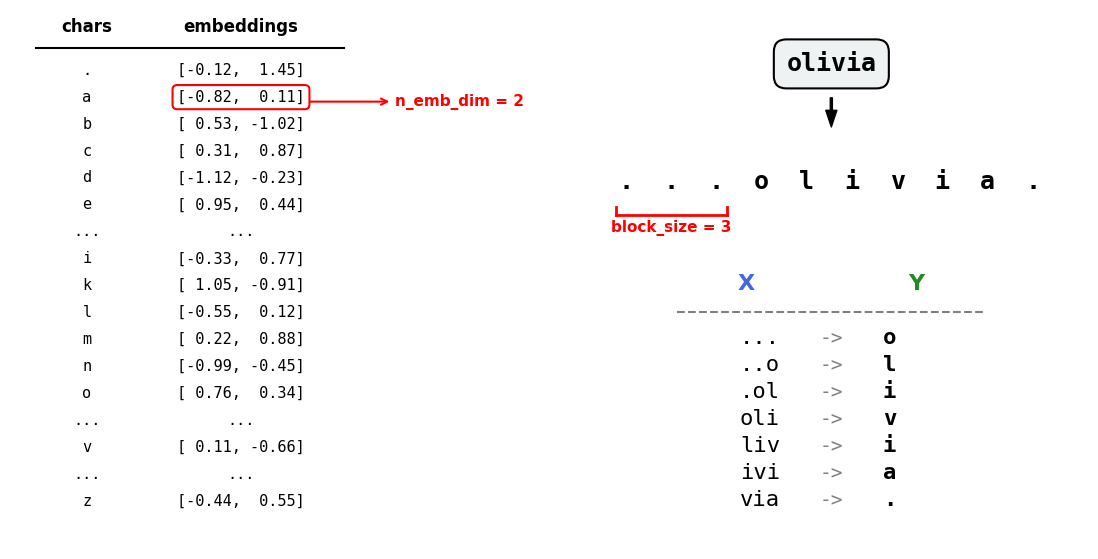

In [3]:
# görselleştirme

import matplotlib.pyplot as plt

# 1 satır, 2 sütun şeklinde yan yana grafik oluşturuyoruz (Genişlik 11, Yükseklik 5.5)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5.5))

# ==========================================
# SOL TARAF (ax1): Embedding Tablosu
# ==========================================
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')

chars_to_show = ['.', 'a', 'b', 'c', 'd', 'e', '...', 'i', 'k', 'l', 'm', 'n', 'o', '...', 'v', '...', 'z']
embs_to_show = [
    "[-0.12,  1.45]", "[-0.82,  0.11]", "[ 0.53, -1.02]", "[ 0.31,  0.87]", 
    "[-1.12, -0.23]", "[ 0.95,  0.44]", "...", 
    "[-0.33,  0.77]", "[ 1.05, -0.91]", "[-0.55,  0.12]", 
    "[ 0.22,  0.88]", "[-0.99, -0.45]", "[ 0.76,  0.34]", 
    "...", "[ 0.11, -0.66]", "...", "[-0.44,  0.55]"
]

ax1.text(0.15, 0.96, "chars", fontsize=12, fontweight='bold', ha='center')
ax1.text(0.45, 0.96, "embeddings", fontsize=12, fontweight='bold', ha='center')
ax1.plot([0.05, 0.65], [0.93, 0.93], color='black', lw=1.5)

y_start = 0.88
y_step = 0.05

for i, (c, e) in enumerate(zip(chars_to_show, embs_to_show)):
    y = y_start - i * y_step
    
    ax1.text(0.15, y, c, fontsize=11, ha='center', fontfamily='monospace')
    
    if c == 'a':
        # 1. Kırmızı daire/kutu içine alma
        bbox_props = dict(boxstyle="round,pad=0.3", ec="red", fc="none", lw=1.5)
        ax1.text(0.45, y, e, fontsize=11, ha='center', fontfamily='monospace', bbox=bbox_props)
        
        # 2. Sağdan soldan sağa doğru uzanan kırmızı ok ve yazı
        ax1.annotate("n_emb_dim = 2", 
                    xy=(0.58, y),       
                    xytext=(0.75, y),   
                    arrowprops=dict(arrowstyle="<-", color="red", lw=1.5),
                    fontsize=11, color='red', va='center', ha='left', fontweight='bold')
    else:
        ax1.text(0.45, y, e, fontsize=11, ha='center', fontfamily='monospace')


# ==========================================
# SAĞ TARAF (ax2): "olivia" Ayrıştırması
# ==========================================
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')

# 1) Kutu içinde "olivia" kelimesi
bbox_props_olivia = dict(boxstyle="round,pad=0.5", fc="#eef2f3", ec="black", lw=1.5)
ax2.text(0.5, 0.90, "olivia", fontsize=18, ha='center', va='center', bbox=bbox_props_olivia, fontfamily='monospace', fontweight='bold')

# 2) Yukarıdan aşağıya doğru ok
ax2.annotate('', xy=(0.5, 0.78), xytext=(0.5, 0.84),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8))

# 3) Harflere ayrılmış hali
word_padded = ['.', '.', '.'] + list('olivia') + ['.']
x_start_olivia = 0.1
x_step_olivia = 0.088
x_positions = [x_start_olivia + i * x_step_olivia for i in range(len(word_padded))]

for x, ch in zip(x_positions, word_padded):
    ax2.text(x, 0.68, ch, fontsize=18, ha='center', va='center', fontfamily='monospace', fontweight='bold')

# 4) İlk 3 noktanın (... ) altına yatay "{" 
bx_start = x_positions[0] - 0.02
bx_end = x_positions[2] + 0.02
y_brace = 0.62

ax2.plot([bx_start, bx_end], [y_brace, y_brace], color='red', lw=2)
ax2.plot([bx_start, bx_start], [y_brace, y_brace+0.015], color='red', lw=2)
ax2.plot([bx_end, bx_end], [y_brace, y_brace+0.015], color='red', lw=2)
ax2.text((bx_start+bx_end)/2, y_brace-0.01, "block_size = 3", color='red', fontsize=11, ha='center', va='top', fontweight='bold')

# 5) Adım adım X ve Y gösterimi
steps = [
    ("...", "o"),
    ("..o", "l"),
    (".ol", "i"),
    ("oli", "v"),
    ("liv", "i"),
    ("ivi", "a"),
    ("via", ".")
]

# Başlıklar
ax2.text(0.35, 0.48, "X", fontsize=16, ha='right', fontweight='bold', color='royalblue')
ax2.text(0.65, 0.48, "Y", fontsize=16, ha='left', fontweight='bold', color='forestgreen')
ax2.plot([0.2, 0.8], [0.44, 0.44], color='gray', lw=1.5, linestyle="--")

# Satırlar
y_step_olivia = 0.38
for i, (x_str, y_str) in enumerate(steps):
    y_pos = y_step_olivia - i*0.05
    ax2.text(0.40, y_pos, x_str, fontsize=16, ha='right', fontfamily='monospace')
    ax2.text(0.50, y_pos, "->", fontsize=14, ha='center', fontfamily='monospace', color='gray')
    ax2.text(0.60, y_pos, y_str, fontsize=16, ha='left', fontfamily='monospace', fontweight='bold')

# Boşlukları ayarla ve göster
plt.subplots_adjust(wspace=0.1, left=0.01, right=0.99, top=0.99, bottom=0.01)
plt.show()


In [4]:
# Görev 2: 
    ## Gizli katmanı ve çıkış katmanını kur: 
        ### embedding'leri düzleştir
        ### W1 ve b1 ile tanh, W2 ve b2 ile logits. 
        ### Loss'u geçen haftaki gibi elle hesapla, sonra F.cross_entropy ile aynı sonucu aldığını göster
            #### neden onu tercih ettiğimizi videodan anla. 


W1 = torch.randn((6,100))
b1 = torch.randn(100)
    ## => Neden 6 değil 100?
        ### (32,6) @ (6,100) => (32,100)
        ### haliyle (32,100) + (6,) olmaz
        ### => (32,100) + (100,) nmasıl olur?
            #### -> pytorch, başa 1 ekler eksik dimension varsa
            #### (32,100) + (1, 100) olur
    ## -> Aklında olsun:
        ## W: ( (önceki layer neuron sayı, sonraki layer neuron sayı) )
        ## b: ( sonraki layer neuron sayı )
            ## b, direkt sonraki layer'daki neuronlara ait

h = torch.tanh(emb.view(-1,6) @ W1 + b1)

    ## => Neden (100,27)?
        ### ==> Neden 100?
            #### Hidden Layer -> Output'tayız
            #### Önceki (hidden) layer'da 100 neuron vardı
        ### ==> Neden 27?
            #### 27 output var
                ##### her char için olasılık

W2 = torch.randn((100,27))
b2 = torch.randn(27)


logits = h @ W2 + b2

counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)


loss = -probs[torch.arange(Y.shape[0]), Y].log().mean()
loss

tensor(21.1948)

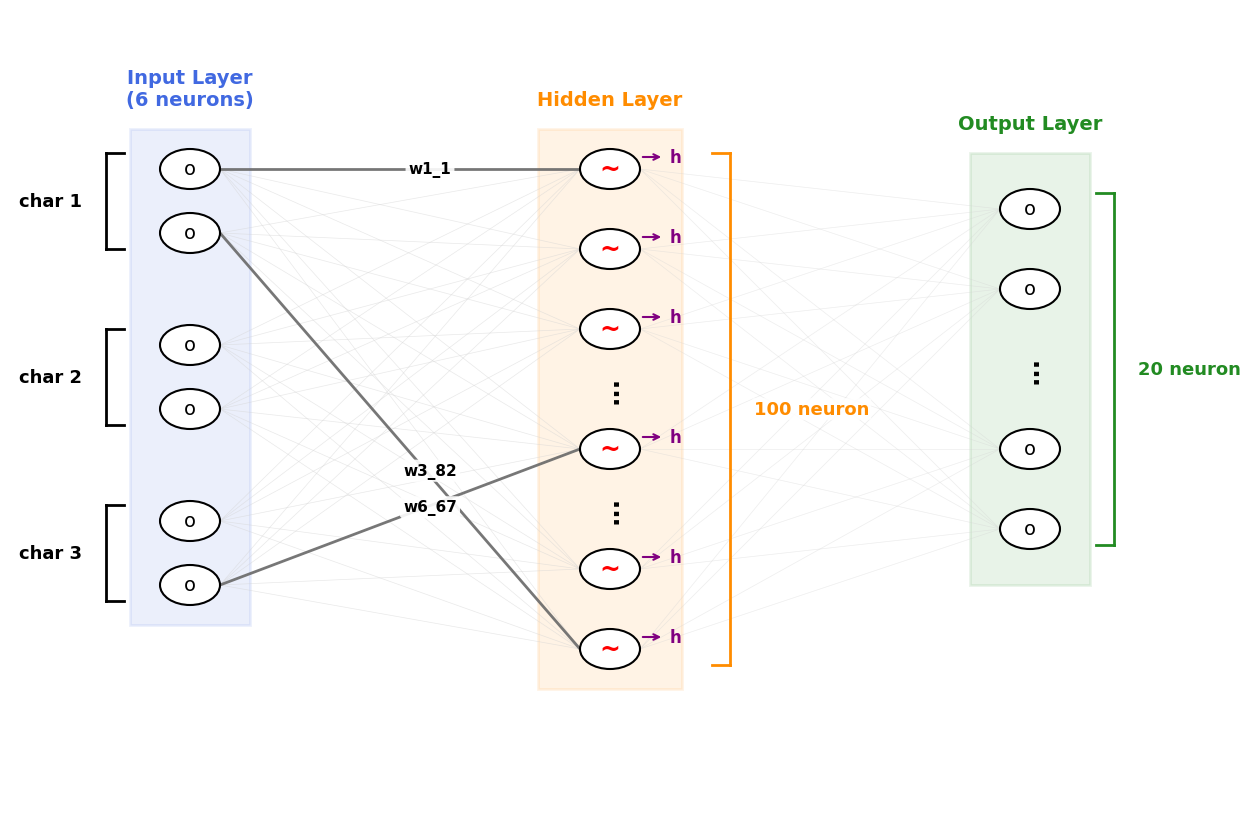

In [5]:
# görselleştirme

import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

node_radius = 0.025

# =========================================================
# YARDIMCI FONKSİYON: Süslü parantez yerine şık braket çizimi
# =========================================================
def draw_bracket(ax, x, y_top, y_bot, direction='right', text='', text_x=0, text_y=0, color='black'):
    # Z-order ekledik ki çizgilerin üstünde kalsın
    ax.plot([x, x], [y_bot, y_top], color=color, lw=2, zorder=4)
    w = 0.015 if direction == 'right' else -0.015
    ax.plot([x, x+w], [y_bot, y_bot], color=color, lw=2, zorder=4)
    ax.plot([x, x+w], [y_top, y_top], color=color, lw=2, zorder=4)
    if text:
        ha = 'right' if direction == 'right' else 'left'
        # Çizgilerin üstüne binince okunması için beyaz arka plan eklendi
        bbox = dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.9)
        ax.text(text_x, text_y, text, ha=ha, va='center', fontsize=13, color=color, fontweight='bold', bbox=bbox, zorder=5)

# ================================
# 1. INPUT LAYER (char 1, char 2, char 3)
# ================================
x_in = 0.15
y_in = [0.8, 0.72,   0.58, 0.50,   0.36, 0.28]

in_box = patches.Rectangle((x_in-0.05, 0.23), 0.1, 0.62, linewidth=2, edgecolor='royalblue', facecolor='royalblue', alpha=0.1)
ax.add_patch(in_box)
ax.text(x_in, 0.88, "Input Layer\n(6 neurons)", ha='center', fontsize=14, fontweight='bold', color='royalblue')

for y in y_in:
    circle = patches.Circle((x_in, y), node_radius, edgecolor='black', facecolor='white', lw=1.5, zorder=3)
    ax.add_patch(circle)
    ax.text(x_in, y, "o", ha='center', va='center', fontsize=14)

draw_bracket(ax, x=x_in-0.07, y_top=0.82, y_bot=0.70, direction='right', text='char 1', text_x=x_in-0.09, text_y=0.76)
draw_bracket(ax, x=x_in-0.07, y_top=0.60, y_bot=0.48, direction='right', text='char 2', text_x=x_in-0.09, text_y=0.54)
draw_bracket(ax, x=x_in-0.07, y_top=0.38, y_bot=0.26, direction='right', text='char 3', text_x=x_in-0.09, text_y=0.32)


# ================================
# 2. HIDDEN LAYER
# ================================
x_hid = 0.5
y_hid_nodes = [0.8, 0.7, 0.6, 0.45, 0.3, 0.2]
y_hid_dots = [0.525, 0.375] 

hid_box = patches.Rectangle((x_hid-0.06, 0.15), 0.12, 0.7, linewidth=2, edgecolor='darkorange', facecolor='darkorange', alpha=0.1)
ax.add_patch(hid_box)
ax.text(x_hid, 0.88, "Hidden Layer", ha='center', fontsize=14, fontweight='bold', color='darkorange')

for y in y_hid_nodes:
    circle = patches.Circle((x_hid, y), node_radius, edgecolor='black', facecolor='white', lw=1.5, zorder=3)
    ax.add_patch(circle)
    ax.text(x_hid, y, "~", ha='center', va='center', fontsize=18, fontweight='bold', color='red', zorder=4)
    
    ax.annotate('', xy=(x_hid+0.045, y+0.015), xytext=(x_hid+node_radius, y+0.015), 
                arrowprops=dict(arrowstyle='->', color='purple', lw=1.5), zorder=4)
    ax.text(x_hid+0.05, y+0.015, "h", color='purple', va='center', ha='left', fontsize=12, fontweight='bold', zorder=5)

for y in y_hid_dots:
    ax.text(x_hid, y, "...", ha='center', va='center', rotation=90, fontsize=18, fontweight='bold')

# === DEĞİŞİKLİK BURADA ===
# { 100 braketi Sola değil Sağ tarafa (x_hid + 0.1) alındı ve "100 neuron" yazıldı
draw_bracket(ax, x=x_hid+0.1, y_top=0.82, y_bot=0.18, direction='left', text='100 neuron', text_x=x_hid+0.12, text_y=0.5, color='darkorange')


# ===============================================
# WEIGHT ÇİZGİLERİ (Input -> Hidden)
# ===============================================
for yi in y_in:
    for yh in y_hid_nodes:
        ax.plot([x_in+node_radius, x_hid-node_radius], [yi, yh], color='lightgray', lw=0.5, alpha=0.5, zorder=1)

def draw_weight(yi, yh, label):
    ax.plot([x_in+node_radius, x_hid-node_radius], [yi, yh], color='dimgray', lw=2, alpha=0.9, zorder=2)
    xm = 0.35 
    t = (xm - x_in) / (x_hid - x_in) 
    ym = yi + t * (yh - yi)
    bbox = dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.9)
    ax.text(xm, ym, label, color='black', fontsize=11, ha='center', va='center', fontweight='bold', bbox=bbox, zorder=5)

draw_weight(y_in[0], y_hid_nodes[0], "w1_1")
draw_weight(y_in[5], y_hid_nodes[3], "w6_67")
draw_weight(y_in[1], y_hid_nodes[5], "w3_82")


# ================================
# 3. OUTPUT LAYER
# ================================
x_out = 0.85
y_out_nodes = [0.75, 0.65, 0.45, 0.35]
y_out_dots = [0.55]

out_box = patches.Rectangle((x_out-0.05, 0.28), 0.1, 0.54, linewidth=2, edgecolor='forestgreen', facecolor='forestgreen', alpha=0.1)
ax.add_patch(out_box)
ax.text(x_out, 0.85, "Output Layer", ha='center', fontsize=14, fontweight='bold', color='forestgreen')

for y in y_out_nodes:
    circle = patches.Circle((x_out, y), node_radius, edgecolor='black', facecolor='white', lw=1.5, zorder=3)
    ax.add_patch(circle)
    ax.text(x_out, y, "o", ha='center', va='center', fontsize=14)

for y in y_out_dots:
    ax.text(x_out, y, "...", ha='center', va='center', rotation=90, fontsize=18, fontweight='bold')

# } 20 neuron braketi (Sağ taraftan)
draw_bracket(ax, x=x_out+0.07, y_top=0.77, y_bot=0.33, direction='left', text='20 neuron', text_x=x_out+0.09, text_y=0.55, color='forestgreen')

# Hidden -> Output bağlantıları
for yh in y_hid_nodes:
    for yo in y_out_nodes:
        ax.plot([x_hid+node_radius, x_out-node_radius], [yh, yo], color='lightgray', lw=0.5, alpha=0.4, zorder=1)

plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()

15.459324836730957
7.439990043640137
3.069641590118408
0.754374086856842
0.09722664207220078
0.02995343878865242
0.023246929049491882
0.019360912963747978
0.016751736402511597
0.014851117506623268
0.013391157612204552
0.012226924300193787
0.011271859519183636
0.010471413843333721
0.009788883849978447
0.009198478423058987
0.00868176855146885
0.008225123398005962
0.007818017154932022
0.007452565245330334
0.007122264243662357
0.00682208314538002
0.006547859404236078
0.006296371575444937
0.006064604036509991
0.0058503905311226845
0.005651539191603661
0.005466589238494635
0.005294030532240868
0.005132470279932022
0.004981084726750851
0.0048388103023171425
0.004704797174781561
0.004578406922519207
0.0044588129967451096
0.004345637746155262
0.004238289315253496
0.004136319272220135
0.004039395600557327
0.003947046585381031
0.003859081771224737
0.0037749814800918102
0.003694674465805292
0.0036178529262542725
0.003544185310602188
0.0034737191163003445
0.003405933501198888
0.0033409707248210907


torch.return_types.max(
values=tensor([21.1468, 16.4452, 15.5275, 20.0309, 21.4814], grad_fn=<MaxBackward0>),
indices=tensor([25, 21,  8,  5, 14]))

16.931093215942383
15.089313507080078
16.844181060791016
12.635926246643066
13.142440795898438
14.364885330200195
9.377059936523438
10.991921424865723
13.247499465942383
11.671841621398926
10.88663101196289
10.14210319519043
10.398672103881836
9.047798156738281
8.984972953796387
10.427383422851562
7.211366653442383
11.529215812683105
9.928409576416016
8.33000659942627
7.112955570220947
8.170763969421387
8.169154167175293
8.439529418945312
7.392553806304932
7.169904708862305
8.710773468017578
7.19785213470459
8.635444641113281
5.78986120223999
6.793071746826172
6.616250991821289
5.565699100494385
6.044342517852783
4.738836765289307
5.907766819000244
6.719862937927246
4.999091148376465
6.320103168487549
6.468102931976318
6.466267108917236
6.113401889801025
5.67859411239624
6.231309413909912
7.105642318725586
4.217108249664307
5.670322418212891
5.9582600593566895
4.036012649536133
4.416345596313477
5.16071081161499
4.706238269805908
6.239640712738037
5.5769734382629395
4.3991851806640625


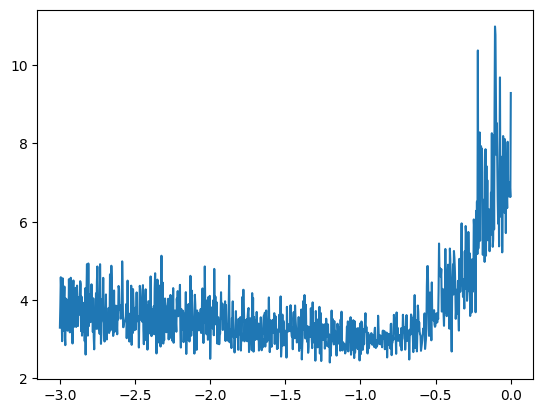

In [22]:
# Görev 3: 
    ## Eğitim döngüsünü kur: 
        ### önce tek bir minibatch'i overfit et
        ### sonra bütün veriyi minibatch'lerle eğit
    ## Learning rate'i videodaki gibi tara ve iyi bir değer seç
    ## Veriyi train / dev / test olarak böl, loss'u dev üzerinde raporla.


g = torch.Generator().manual_seed(2147483647) 
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

# overfitting (32 data - 3481 parameter)
X,Y,_,_,_,_ = prepare_training_set()
X = X[:5]
Y = Y[:5]

for _ in range(100):
    # forward pass
    emb = C[X] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)

    # F.cross_entropy(...) bunların hepsini yapıyo
    
    #counts = logits.exp()
    #probs  = counts / counts.sum(1, keepdim=True)

    #loss = -probs[torch.arange(32), Y].log().mean()
    
    loss = F.cross_entropy(logits, Y)
    print(loss.item())


    # backward pass
    for p in parameters:
        p.grad = None   # = 0.0 demek ile aynıymış
    
    loss.backward()     # p.grad'ları yeniden hesapladık

    for p in parameters:
        p.data += -0.1 * p.grad
display(logits.max(1)) # overfit kanıtı



# tüm datayı minibatchler ile eğitmek
X,Y,_,_,_,_ = prepare_training_set()

for _ in range(100):
    # minibatching
    ix = torch.randint(0, X.shape[0], (32,))

    # forward pass
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)

    # F.cross_entropy(...) bunların hepsini yapıyo
    
    #counts = logits.exp()
    #probs  = counts / counts.sum(1, keepdim=True)

    #loss = -probs[torch.arange(32), Y].log().mean()
    
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())


    # backward pass
    for p in parameters:
        p.grad = None   # = 0.0 demek ile aynıymış
    
    loss.backward()     # p.grad'ları yeniden hesapladık

    for p in parameters:
        p.data += -0.1 * p.grad
"""




# iyi lr değeri bulmak
"""
X,Y,_,_,_,_ = prepare_training_set()

# lr = 0.001 - 1 (e^-3 - e^0 arası) arasında iyi değer arıyoruz
lre = torch.linspace(-3, 0 , 1000)
lrs = 10 ** lre
lri = []
lossi = []

for i in range(1000):
    # minibatching
    ix = torch.randint(0, X.shape[0], (32,))

    # forward pass
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)

    # F.cross_entropy(...) bunların hepsini yapıyo
    
    #counts = logits.exp()
    #probs  = counts / counts.sum(1, keepdim=True)

    #loss = -probs[torch.arange(32), Y].log().mean()
    
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())


    # backward pass
    for p in parameters:
        p.grad = None   # = 0.0 demek ile aynıymış
    
    loss.backward()     # p.grad'ları yeniden hesapladık

    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad
    
    lri.append(lre[i])
    lossi.append(loss.item())

plt.plot(lri, lossi)


# dataseti, "train/dev/test" olarak ayırma
X_tr, Y_tr, X_dev, Y_dev, X_te, Y_te = prepare_training_set()


for i in range(10000):
    # minibatching
    ix = torch.randint(0, X_tr.shape[0], (32,))

    # forward pass
    emb = C[X_tr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)

    # F.cross_entropy(...) bunların hepsini yapıyo
    
    #counts = logits.exp()
    #probs  = counts / counts.sum(1, keepdim=True)

    #loss = -probs[torch.arange(32), Y].log().mean()
    
    loss = F.cross_entropy(logits, Y_tr[ix])
    print(loss.item())


    # backward pass
    for p in parameters:
        p.grad = None   # = 0.0 demek ile aynıymış
    
    loss.backward()     # p.grad'ları yeniden hesapladık

    lr = 0.1 # sonra weight decay uyguanıp lr=0.01 yapılabilir sonlara doğru
    for p in parameters:
        p.data += -lr * p.grad

# evaluation
def inference(X, Y):
    emb = C[X]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    return loss.item()

# -> sonuçlar yakın ise OVERFIT ETMEDİK demektir
print(f"Train loss: {inference(X_tr,Y_tr)}")
print(f"Dev loss: {inference(X_dev,Y_dev)}")

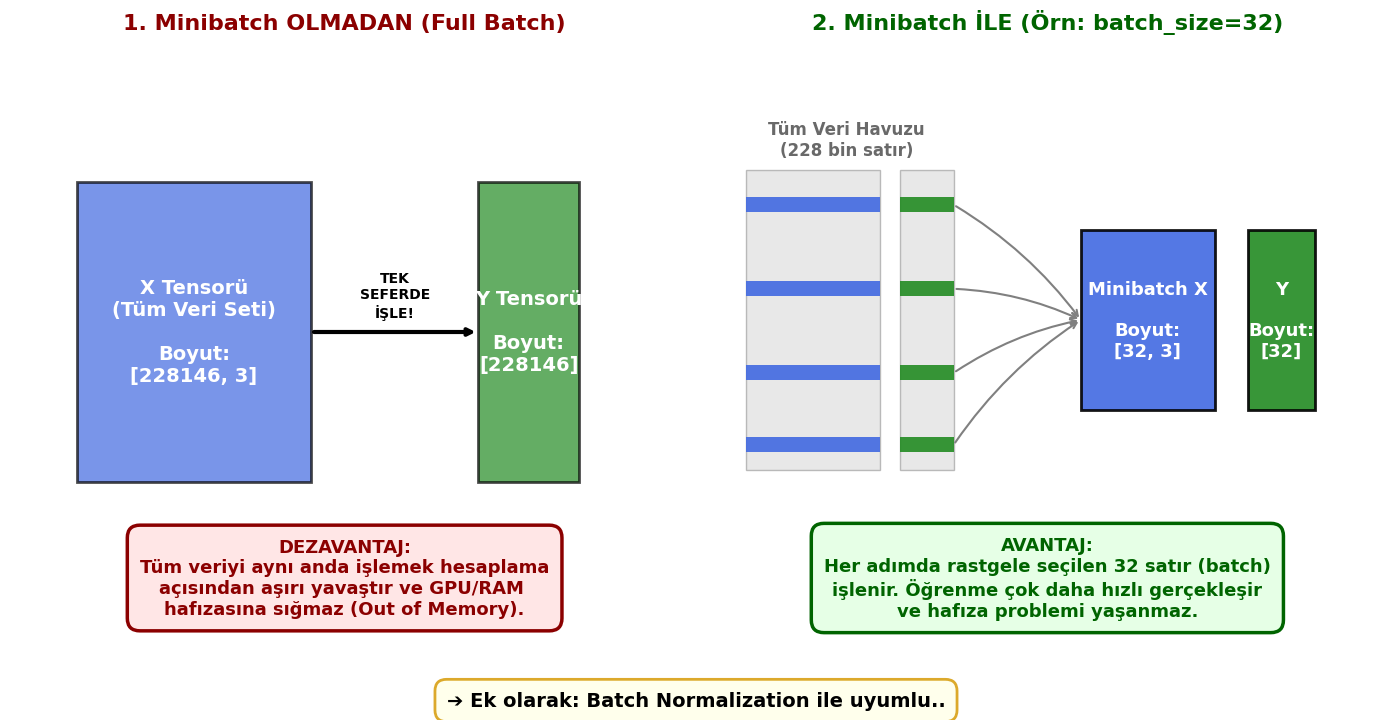

In [7]:
# görselleştirme

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Yüksekliği biraz artırdık (7 -> 7.5), alt kısımda ekstra kutu için alan açtık
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7.5))

# ==========================================
# 1. SOL TARAF: MINIBATCH OLMADAN (FULL BATCH)
# ==========================================
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')
ax1.set_title("1. Minibatch OLMADAN (Full Batch)", fontsize=16, fontweight='bold', color='darkred', pad=15)

# Büyük X Kutusu (Daha sola kaydırıldı, ortaya boşluk açıldı)
ax1.add_patch(patches.Rectangle((0.1, 0.28), 0.35, 0.5, linewidth=2, edgecolor='black', facecolor='royalblue', alpha=0.7))
ax1.text(0.275, 0.53, "X Tensorü\n(Tüm Veri Seti)\n\nBoyut:\n[228146, 3]", ha='center', va='center', color='white', fontweight='bold', fontsize=14)

# Büyük Y Kutusu (Daha sağa kaydırıldı)
ax1.add_patch(patches.Rectangle((0.7, 0.28), 0.15, 0.5, linewidth=2, edgecolor='black', facecolor='forestgreen', alpha=0.7))
ax1.text(0.775, 0.53, "Y Tensorü\n\nBoyut:\n[228146]", ha='center', va='center', color='white', fontweight='bold', fontsize=14)

# Ok ve Açıklaması (Artık üst üste binmeyecek)
ax1.annotate('', xy=(0.7, 0.53), xytext=(0.45, 0.53), 
             arrowprops=dict(arrowstyle="->", color="black", lw=3))
ax1.text(0.575, 0.55, "TEK\nSEFERDE\nİŞLE!", ha='center', va='bottom', fontsize=10, fontweight='bold')

# STICKER 1: Dezavantaj Kutusu
bbox_alert = dict(boxstyle="round,pad=0.7", fc="#ffe6e6", ec="darkred", lw=2.5)
ax1.text(0.5, 0.12, "DEZAVANTAJ:\nTüm veriyi aynı anda işlemek hesaplama\naçısından aşırı yavaştır ve GPU/RAM \nhafızasına sığmaz (Out of Memory).", 
         ha='center', va='center', fontsize=13, bbox=bbox_alert, color='darkred', fontweight='bold')


# ==========================================
# 2. SAĞ TARAF: MINIBATCH İLE (Örn: batch_size=32)
# ==========================================
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')
ax2.set_title("2. Minibatch İLE (Örn: batch_size=32)", fontsize=16, fontweight='bold', color='darkgreen', pad=15)

# Devasa Veri Havuzu (Biraz yukarı kaydırıldı)
ax2.add_patch(patches.Rectangle((0.05, 0.3), 0.2, 0.5, linewidth=1, edgecolor='gray', facecolor='lightgray', alpha=0.5))
ax2.add_patch(patches.Rectangle((0.28, 0.3), 0.08, 0.5, linewidth=1, edgecolor='gray', facecolor='lightgray', alpha=0.5))
ax2.text(0.20, 0.85, "Tüm Veri Havuzu\n(228 bin satır)", ha='center', va='center', fontsize=12, color='dimgray', fontweight='bold')

# Havuz içinden rastgele seçilen satır şeritleri
row_ys = [0.73, 0.59, 0.45, 0.33]
for y in row_ys:
    ax2.add_patch(patches.Rectangle((0.05, y), 0.2, 0.025, facecolor='royalblue', alpha=0.9))
    ax2.add_patch(patches.Rectangle((0.28, y), 0.08, 0.025, facecolor='forestgreen', alpha=0.9))

# Minibatch Kutusu
ax2.add_patch(patches.Rectangle((0.55, 0.4), 0.2, 0.3, linewidth=2, edgecolor='black', facecolor='royalblue', alpha=0.9))
ax2.text(0.65, 0.55, "Minibatch X\n\nBoyut:\n[32, 3]", ha='center', va='center', color='white', fontweight='bold', fontsize=13)

ax2.add_patch(patches.Rectangle((0.8, 0.4), 0.1, 0.3, linewidth=2, edgecolor='black', facecolor='forestgreen', alpha=0.9))
ax2.text(0.85, 0.55, "Y\n\nBoyut:\n[32]", ha='center', va='center', color='white', fontweight='bold', fontsize=13)

# Oklar
for y in row_ys:
    ax2.annotate('', xy=(0.55, 0.55), xytext=(0.36, y+0.012), 
                 arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, connectionstyle="arc3,rad=-0.1"))

# STICKER 2: Avantaj Bilgi Kutusu
bbox_info = dict(boxstyle="round,pad=0.7", fc="#e6ffe6", ec="darkgreen", lw=2.5)
ax2.text(0.5, 0.12, "AVANTAJ:\nHer adımda rastgele seçilen 32 satır (batch)\nişlenir. Öğrenme çok daha hızlı gerçekleşir\nve hafıza problemi yaşanmaz.", 
         ha='center', va='center', fontsize=13, bbox=bbox_info, color='darkgreen', fontweight='bold')


# ==========================================
# STICKER 3: ORTAYA VE EN ALTA YERLEŞEN KUTU
# ==========================================
# Bu kutuyu doğrudan "fig" objesine ekliyoruz. x=0.5 tam yatay orta nokta demektir.
bbox_extra = dict(boxstyle="round,pad=0.6", fc="#ffffeb", ec="goldenrod", lw=2, alpha=0.95)
fig.text(0.5, 0.02, "➔ Ek olarak: Batch Normalization ile uyumlu..", 
         ha='center', va='bottom', fontsize=14, bbox=bbox_extra, color='black', fontweight='bold')


# bottom=0.1 yaparak ana grafikleri biraz yukarı itiyoruz, en alttaki kutuya mükemmel bir yer açıyoruz
plt.subplots_adjust(wspace=0.05, left=0.01, right=0.99, top=0.9, bottom=0.1)
plt.show()

Train loss: 2.0708181858062744
Dev loss: 2.146927833557129


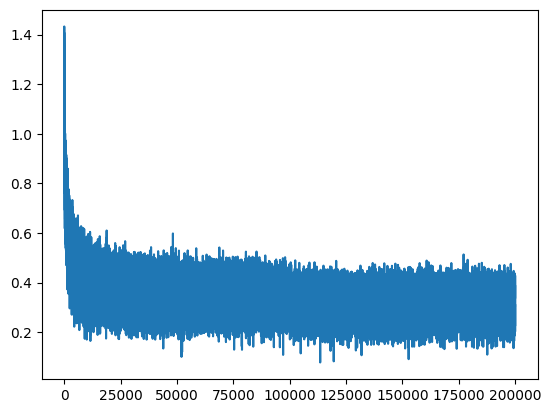

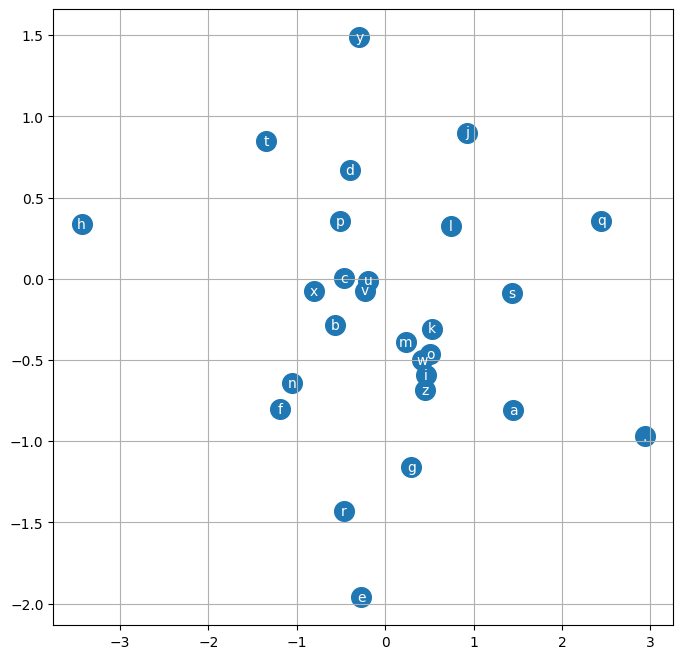

In [8]:
# Görev 4: 
    ## Gizli katmanı ve embedding boyutunu büyütüp dev loss'un nasıl değiştiğini göster. 
    ## Embedding'leri 2 boyutta çizdir: 
        ### hangi harfler birbirine yakın düşüyor? 
        ### Modelden isimler örnekle, bigram'ınkilerle karşılaştır.

# hazırlık

g = torch.Generator().manual_seed(2147483647) 
C = torch.randn((27, 20), generator=g)
W1 = torch.randn((20*3, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

lossi = []
stepi = []

X_tr, Y_tr, X_dev, Y_dev, X_te, Y_te = prepare_training_set()


for i in range(200000):
    # minibatching
    ix = torch.randint(0, X_tr.shape[0], (32,))

    # forward pass
    emb = C[X_tr[ix]]
    h = torch.tanh(emb.view(-1, 60) @ W1 + b1)
    logits = h @ W2 + b2

    loss = F.cross_entropy(logits, Y_tr[ix])
    #print(loss.item())


    # backward pass
    for p in parameters:
        p.grad = None   # = 0.0 demek ile aynıymış
    
    loss.backward()     # p.grad'ları yeniden hesapladık

    # İlk 100.000 adımda büyük adımlarla (0.1) in,
    # Son 100.000 adımda küçük adımlarla (0.01) ince ayar yap.
    lr = 0.1 if i < 100000 else 0.01
    
    for p in parameters:
        p.data += -lr * p.grad

    
    stepi.append(i)
    lossi.append(loss.log10().item())

# evaluation
def inference(X, Y):
    emb = C[X]
    h = torch.tanh(emb.view(-1,60) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    return loss.item()

# -> sonuçlar yakın ise OVERFIT ETMEDİK demektir
print(f"Train loss: {inference(X_tr,Y_tr)}")
print(f"Dev loss: {inference(X_dev,Y_dev)}")

plt.plot(stepi, lossi)


# harf embedding space
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

Olması gereken initial loss (-log(1/27)) : 3.2958

--- KÖTÜ INIT ---
Olan loss: 27.8817



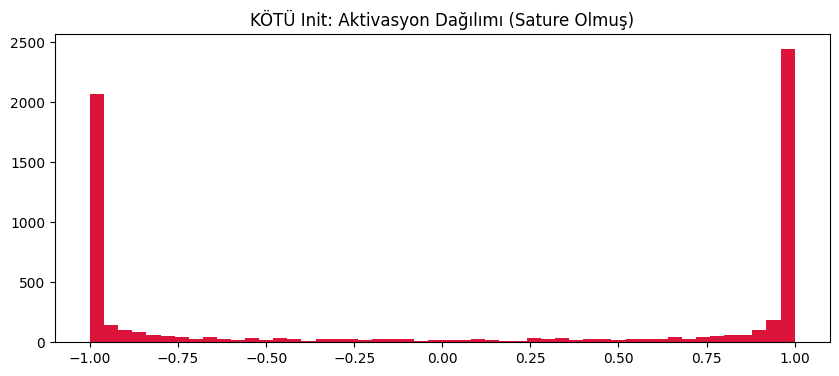

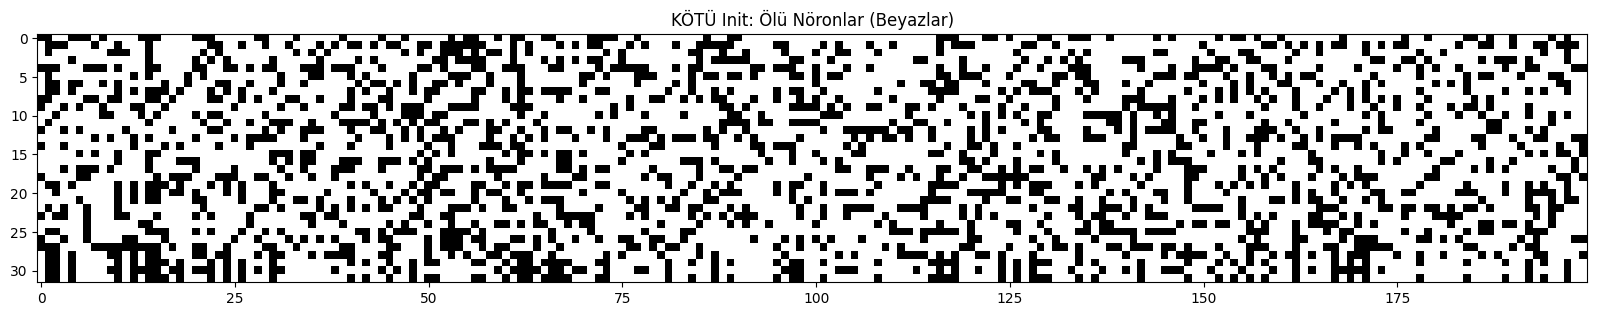

Uniform OLAN Output Örnek: tensor([0.2500, 0.2500, 0.2500, 0.2500])  -  Loss: 1.3862943649291992
Uniform OLMAYAN Output Örnek: tensor([1.1841e-01, 7.9781e-04, 5.8950e-03, 8.7490e-01])  -  Loss: 5.133643627166748

Uniform olmayan outputlar:
tensor([ 0.1373,  1.2042,  1.9442,  0.3094,  2.0192,  0.0086, -0.8007,  0.6120,
         1.7897, -0.6737, -1.2738, -1.1285,  0.2867,  0.1687,  1.1231,  0.6550,
        -2.7028,  1.2879,  0.0094, -0.6419,  1.3549, -1.9539,  1.1204,  0.0237,
         0.8102, -0.7986, -0.2513], requires_grad=True)

--- İYİ INIT (Kaiming Init) Başlangıç Durumu ---
Olan loss (Kaiming ile): 3.3179



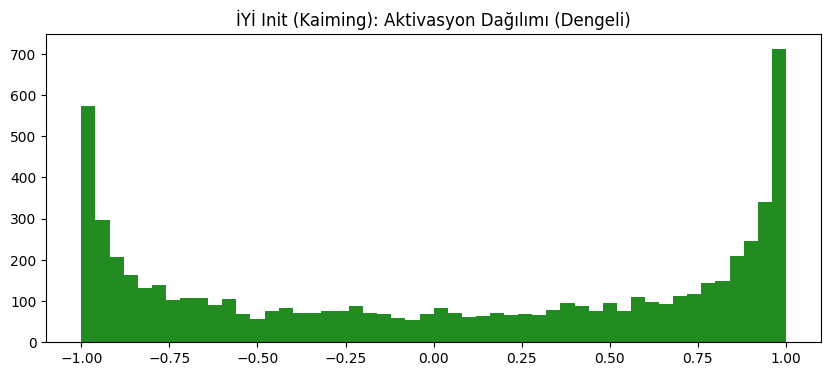

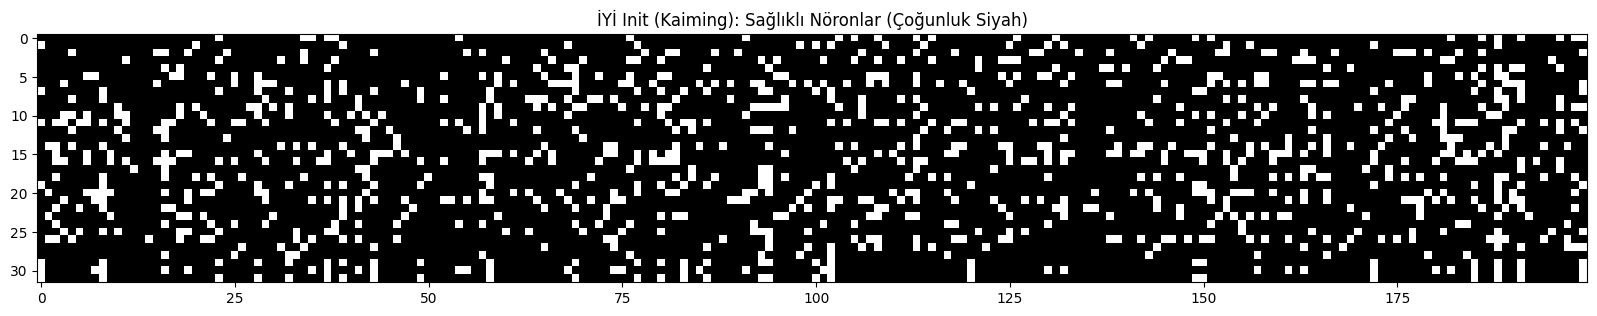


Şimdi Kaiming Init ile Eğitim Başlıyor...

      0/ 200000: 3.3179
  10000/ 200000: 2.1910
  20000/ 200000: 2.3270
  30000/ 200000: 2.5396
  40000/ 200000: 1.9468
  50000/ 200000: 2.3331
  60000/ 200000: 2.3852
  70000/ 200000: 2.1173
  80000/ 200000: 2.3159
  90000/ 200000: 2.2010
 100000/ 200000: 1.8591
 110000/ 200000: 2.0881
 120000/ 200000: 1.9389
 130000/ 200000: 2.3913
 140000/ 200000: 2.0949
 150000/ 200000: 2.1458
 160000/ 200000: 1.7824
 170000/ 200000: 1.7249
 180000/ 200000: 1.9751
 190000/ 200000: 1.8614
train 2.0376641750335693
val 2.106989622116089


In [9]:
# Görev 5: 
    ## Aynı modelde başlangıç loss'unun neden çok yüksek olduğunu ve tanh'ın neden doyduğunu göster
    ## Videodaki histogramı çizdir. 
    ## Kaiming init ile ağırlıkları ölçekle, iki sorunun da düzeldiğini göster

# hazırlık
def init_variables_mlp(n_embd, n_hidden):
    vocab_size = get_vocab_size()
    block_size = get_block_size()
    g = torch.Generator().manual_seed(2147483647) 
    
    C  = torch.randn((vocab_size, n_embd),            generator=g)
    W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
    b1 = torch.randn(n_hidden,                        generator=g)
    W2 = torch.randn((n_hidden, vocab_size),          generator=g)
    b2 = torch.randn(vocab_size,                      generator=g)
    
    parameters = [C, W1, b1, W2, b2]
    for p in parameters:
        p.requires_grad = True
    return g, C, W1, b1, W2, b2, parameters

def train_mlp(n_embd, n_hidden, max_steps=200000, batch_size=32):
    g, C, W1, b1, W2, b2, parameters = init_variables_mlp(n_embd, n_hidden)
    lossi = []
    
    for i in range(max_steps):
        ix = torch.randint(0, X_tr.shape[0], (batch_size,), generator=g)
        Xb, Yb = X_tr[ix], Y_tr[ix]
        
        emb = C[Xb]
        embcat = emb.view(emb.shape[0], -1)
        hpreact = embcat @ W1 + b1
        h = torch.tanh(hpreact)
        logits = h @ W2 + b2
        loss = F.cross_entropy(logits, Yb)
        
        for p in parameters:
            p.grad = None
        loss.backward()
        
        lr = 0.1 if i < 100000 else 0.01
        for p in parameters:
            p.data += -lr * p.grad
            
        if i % 10000 == 0:
            print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
            lossi.append(loss.log10().item())
    return C, W1, b1, W2, b2

@torch.no_grad()
def split_loss(split, C, W1, b1, W2, b2):
    x, y = {'train': (X_tr, Y_tr), 'val': (X_dev, Y_dev), 'test': (X_te, Y_te)}[split]
    emb = C[x] 
    embcat = emb.view(emb.shape[0], -1) 
    h = torch.tanh(embcat @ W1 + b1) 
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

def init_variables_mlp_without_batch_norm(n_embd, n_hidden):
    vocab_size = get_vocab_size()
    block_size = get_block_size()
    g = torch.Generator().manual_seed(2147483647) 
    
    C = torch.randn((vocab_size, n_embd), generator=g)
    # kaiming init böyle tanh için -> (5/3) / sqrt(input sayısı)
    W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / ((n_embd * block_size) ** 0.5) 
    b1 = torch.randn(n_hidden, generator=g) * 0.01  
    W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
    b2 = torch.randn(vocab_size, generator=g) * 0     
    
    parameters = [C, W1, b1, W2, b2]
    for p in parameters:
        p.requires_grad = True
    return g, C, W1, b1, W2, b2, parameters

def train_mlp_without_batch_norm(n_embd, n_hidden, max_steps=200000, batch_size=32, show=True):
    g, C, W1, b1, W2, b2, parameters = init_variables_mlp_without_batch_norm(n_embd, n_hidden)
    lossi = []
    
    for i in range(max_steps):
        ix = torch.randint(0, X_tr.shape[0], (batch_size,), generator=g)
        Xb, Yb = X_tr[ix], Y_tr[ix]
        
        emb = C[Xb]
        embcat = emb.view(emb.shape[0], -1)
        hpreact = embcat @ W1 + b1
        h = torch.tanh(hpreact)
        logits = h @ W2 + b2
        loss = F.cross_entropy(logits, Yb)
        
        for p in parameters:
            p.grad = None
        loss.backward()
        
        lr = 0.1 if i < 100000 else 0.01
        for p in parameters:
            p.data += -lr * p.grad
            
        if i % 10000 == 0 and show:
            print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
            lossi.append(loss.log10().item())
    return C, W1, b1, W2, b2

@torch.no_grad()
def split_loss_without_batch_norm(split, C, W1, b1, W2, b2): 
    x, y = {'train': (X_tr, Y_tr), 'val': (X_dev, Y_dev), 'test': (X_te, Y_te)}[split]
    emb = C[x] 
    embcat = emb.view(emb.shape[0], -1) 
    h = torch.tanh(embcat @ W1 + b1) 
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())



X_tr, Y_tr, X_dev, Y_dev, X_te, Y_te = prepare_training_set()


# KÖTÜ INIT
print(f"Olması gereken initial loss (-log(1/27)) : {-torch.tensor(1.0/27.0).log().item():.4f}\n")

print("--- KÖTÜ INIT ---")
g, C, W1, b1, W2, b2, parameters = init_variables_mlp(10, 200)

# Sadece 1 batch çekip h'yi buluyoruz
ix = torch.randint(0, X_tr.shape[0], (32,), generator=g)
emb = C[X_tr[ix]]
h_bad = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)
logits_bad = h_bad @ W2 + b2
loss_bad = F.cross_entropy(logits_bad, Y_tr[ix])
print(f"Olan loss: {loss_bad.item():.4f}\n")

plt.figure(figsize=(10, 4))
plt.hist(h_bad.view(-1).tolist(), bins=50, color='crimson')
plt.title("KÖTÜ Init: Aktivasyon Dağılımı (Sature Olmuş)")
plt.show()

plt.figure(figsize=(20, 5))
plt.imshow(h_bad.abs() > 0.97, cmap='gray', interpolation='nearest')
plt.title("KÖTÜ Init: Ölü Nöronlar (Beyazlar)")
plt.show()

## => Neden tanh saturated oluyo? 
    ### hep ya -1 ya da 1 oluyo
    ### sonra da, _backwards() a başlarken şu oluyo:
        #### def tanh():
                # ... 
                # def _backward():
                    # out = (1 - t ^2) * out.grad
                # -> e "out" hep 0
                # -> e grad ASLA ÖĞRENİLEMEZ
## => Her şey 0 oluyor ise; öğrenme nasıl olabiliyor?
    ### -> Tüm sonuçlar -1 veya 1 değil
    ### öyle olmayanlar ile train oluyo... ama verimsiz oluyo işte
        #### boşa gidiyo -1 ve 1 olanlar
## -> ama, karmaşık örneklerde durum böyle değil:
    ### -> hatalar stacked up oluyor
        #### hatta, sırf "bad initialization" yüzünden train olamadığı oluyo
        #### 50 layer'lı neuron düşün... hatalar birikir, birikir, birikir




# initial loss, expected olmalı
    ## high olur, ama aşırı high ise sorun varmış
    ## => kaç olmalıydı?
        ### -torch.tensor(1 / 27.0).log() # -> 3.29
    ## -> sorun şuydu: "init etme şeklimiz" yanlıştı
        ### (en başta) her output'un 'eşit olasılığı' olmalı idi
            #### random init edince, bazı outputlar daha fazla bazısı daha az şansa sahip

# doğru
    ## tüm output'lar eşit şansa sahip
logits = torch.tensor([0.0, 0.0, 0.0, 0.0])
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
print(f"Uniform OLAN Output Örnek: {probs}  -  Loss: {loss}") # (tensor([0.2500, 0.2500, 0.2500, 0.2500]), tensor(1.3863))

# yanlış 
    ## bazı output'ların şansı daha yüksek
logits = torch.tensor([3.0, -2.0, 0.0, 5.0])
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
print(f"Uniform OLMAYAN Output Örnek: {probs}  -  Loss: {loss}") # tensor([0.0066, 0.0066, 0.0066, 0.9802]) tensor(5.0200)

print(f"\nUniform olmayan outputlar:\n{b2}\n")




# İYİ (KAIMING İLE) INIT
print("--- İYİ INIT (Kaiming Init) Başlangıç Durumu ---")
g, C, W1, b1, W2, b2, parameters = init_variables_mlp_without_batch_norm(10, 200)

# Sadece 1 batch çekip h'yi buluyoruz
ix = torch.randint(0, X_tr.shape[0], (32,), generator=g)
emb = C[X_tr[ix]]
h_good = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)
logits_good = h_good @ W2 + b2
loss_good = F.cross_entropy(logits_good, Y_tr[ix])
print(f"Olan loss (Kaiming ile): {loss_good.item():.4f}\n")

plt.figure(figsize=(10, 4))
plt.hist(h_good.view(-1).tolist(), bins=50, color='forestgreen')
plt.title("İYİ Init (Kaiming): Aktivasyon Dağılımı (Dengeli)")
plt.show()

plt.figure(figsize=(20, 5))
plt.imshow(h_good.abs() > 0.97, cmap='gray', interpolation='nearest')
plt.title("İYİ Init (Kaiming): Sağlıklı Nöronlar (Çoğunluk Siyah)")
plt.show()


print("\nŞimdi Kaiming Init ile Eğitim Başlıyor...\n")
C, W1, b1, W2, b2 = train_mlp_without_batch_norm(n_embd=10, n_hidden=200, max_steps=200000)

split_loss_without_batch_norm('train', C, W1, b1, W2, b2)
split_loss_without_batch_norm('val', C, W1, b1, W2, b2)


In [ ]:
# Görev 6: 
    ## BatchNorm katmanını gizli katmandan sonra ekle. 
    ## Eğitim sırasında batch istatistiği, tahmin sırasında running mean kullan. 
    ## BatchNorm'lu ve BatchNorm'suz modelin dev loss'unu karşılaştır.


# hazırlık
def init_variables_mlp_with_batch_norm(n_embd, n_hidden):
    vocab_size = get_vocab_size()
    block_size = get_block_size()
    g = torch.Generator().manual_seed(2147483647) 

    C = torch.randn((vocab_size, n_embd),             generator=g)
    W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / (n_embd * block_size) ** 0.5
    b1 = torch.randn(n_hidden,                        generator=g) * 0.01 
    W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
    b2 = torch.randn(vocab_size,                      generator=g) * 0    
    
    ## => OLAY NE?
        ### logits çıktımız var
        ### bunu "normalize kalacak şekilde" büyütmek/küçültmek istiyoruz
            ### => NEDEN İSTENEBİLİR BU?
                #### batch norm yaptık
                #### ondan hareketle sonuç bulduk
                #### bu sonuç çok küçük/büyük olabilir
                    ##### onu (bozmadan/normalize şekilde) kontrol etmek/değiştirmek için
        ### final çıktı = bngain * (logits) + bnbias
    bngain = torch.ones((1, n_hidden))  # gamma -> 1 çünkü çarpma  yapıyo (1 olunca etkisiz)
    bnbias = torch.zeros((1, n_hidden)) # beta  -> 0 çünkü toplama yapıyo (0 olunca etkisiz)

    ## => OLAY NE?
        ## inference için batch yok
        ## "batch olsa ortalama ne olurdu? - std.dev ne olurdu?"
            ### -> Bunları bulmak lazım
                #### Ondan, train zamanı hesaplar
                #### -> Tüm batch'lerin "mean'lerinin mean'i"
                #### -> Tüm batch'lerin "std.dev'lerinin mean'i"
    bnmean_running = torch.zeros((1, n_hidden)) # 0 -> çünkü (x - μ / σ) (0 dan çıkaralım ki etkisiz olsun)
    bnstd_running = torch.ones((1, n_hidden))   # 1 -> çünkü (x - μ / σ) (payda 1 olcak ki etkisiz olsun)

    parameters = [C, W1, b1, W2, b2, bngain, bnbias]

    for p in parameters:
        p.requires_grad = True
    
    return g,C,W1,b1,W2,b2,bngain,bnbias, bnmean_running, bnstd_running, parameters

def train_mlp_with_batch_norm(n_embd, n_hidden, max_steps=200000, batch_size = 32, show=True):
    g,C,W1,b1,W2,b2,bngain,bnbias, bnmean_running, bnstd_running, parameters = init_variables_mlp_with_batch_norm(n_embd, n_hidden)
    lossi = []

    for i in range(max_steps):
        # minibatch construct
        ix = torch.randint(0, X_tr.shape[0], (batch_size,), generator=g)
        Xb, Yb = X_tr[ix], Y_tr[ix] 

        # forward pass
        emb = C[Xb]
        embcat = emb.view(emb.shape[0], -1) 
        hpreact = embcat @ W1 + b1 
        
        # O anki batch'in mean ve std'si
        bnmeani = hpreact.mean(0, keepdim=True)
        bnstdi = hpreact.std(0, keepdim=True)
        
        # Batch Norm Formülü
        hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias 
        
        with torch.no_grad():
            ## => 0.999 ne? 0.0001 ne? nerden çıktılar?
                ### "momentum" deniyor buna
                ### elimizde, "ortalamalar ortalaması" ve "std.dev'ler ortalaması" var ya
                ### "elimizde olan" ve "yeni eklenen" var ya
                ### -> şunu yapıyo momentum:
                    #### "elimizde olan ne kadar korunur?"
                    #### "yeni eklenen ne kadar eklenir?"
            ## 𝜇_running ← (1−momentum) ⋅ 𝜇_running + momentum ⋅ 𝜇_ batch
            
            bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
            bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

        h = torch.tanh(hpreact) 
        logits = h @ W2 + b2
        loss = F.cross_entropy(logits, Yb)

        # backward pass
        for p in parameters:
            p.grad = None
        loss.backward()

        # update
        lr = 0.1 if i < 100000 else 0.01 
        for p in parameters:
            p.data += -lr * p.grad

        if i % 10000 == 0 and show: 
            print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
            lossi.append(loss.log10().item())
        
    return C, W1, b1, W2, b2, bngain, bnbias, bnmean_running, bnstd_running

@torch.no_grad()
def split_loss_with_batch_norm(split, C, W1, b1, W2, b2, bngain, bnbias, bnmean_running, bnstd_running):
    x,y = {
        'train': (X_tr, Y_tr),
        'val': (X_dev, Y_dev),
        'test': (X_te, Y_te),
    }[split]
    
    emb = C[x] 
    embcat = emb.view(emb.shape[0], -1) 
    
    hpreact = embcat @ W1 + b1   
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    
    h = torch.tanh(hpreact) 
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())


C, W1, b1, W2, b2, bngain, bnbias, bnmean_running, bnstd_running = train_mlp_with_batch_norm(n_embd=10, n_hidden=200)

split_loss_with_batch_norm('train', C, W1, b1, W2, b2, bngain, bnbias, bnmean_running, bnstd_running)
split_loss_with_batch_norm('val', C, W1, b1, W2, b2, bngain, bnbias, bnmean_running, bnstd_running)



# -> batchnorm
    ## (adından da belli) normalization yapar
        ### bir mean bir std.dev. hesaplar
        ### sayıları normalize eder
        ### => mean ve std.dev nerden bulur/hesaplar?
            #### minibatching yaptık ya
            #### o batch'teki sayılar arasından hesaplar

    ## => Neyi normalize eder? Input'ları mı? w'ları mı?
        ### İkisi de değil...
        ### -> "input @ W"nun sonucunu normalize eder

# -> batchnorm tehlikesi şu:
    ## batch'teki sayıların "ortalamasını" alır... ondan "örnekler birbirlerini kirletir"
        ### -> ilginç: sayısal ortalama/noise pad eder, overfitting önler
            #### -> ondan val'ler aynı... ama train'de daha kötü
# -> çarpma işlemi olan layer sonrası kullanılırmış:
    ## linear (w @ x + b)
    ## convolution

# => neden runnig_mean ve running_std_dev?
    ## bu (batch'lerin) "mean ve std.dev alma" işi okey 
    ## ama inference'da yok bir batch/ortalama
    ## -> train'de olan ortalamalrı tutuyoruz, stabel'lık sağlasın diye

# batch norm sayesinde, 5/3 ile mi 1.0 ile mi başlattık önemi kalmıyo weightleri (tanh activation da)

      0/ 200000: 3.3147
  10000/ 200000: 2.1984
  20000/ 200000: 2.3375
  30000/ 200000: 2.4359
  40000/ 200000: 2.0119
  50000/ 200000: 2.2595
  60000/ 200000: 2.4775
  70000/ 200000: 2.1020
  80000/ 200000: 2.2788
  90000/ 200000: 2.1862
 100000/ 200000: 1.9474
 110000/ 200000: 2.3010
 120000/ 200000: 1.9837
 130000/ 200000: 2.4523
 140000/ 200000: 2.3839
 150000/ 200000: 2.1987
 160000/ 200000: 1.9733
 170000/ 200000: 1.8668
 180000/ 200000: 1.9973
 190000/ 200000: 1.8347
train 2.06659197807312
val 2.1050572395324707


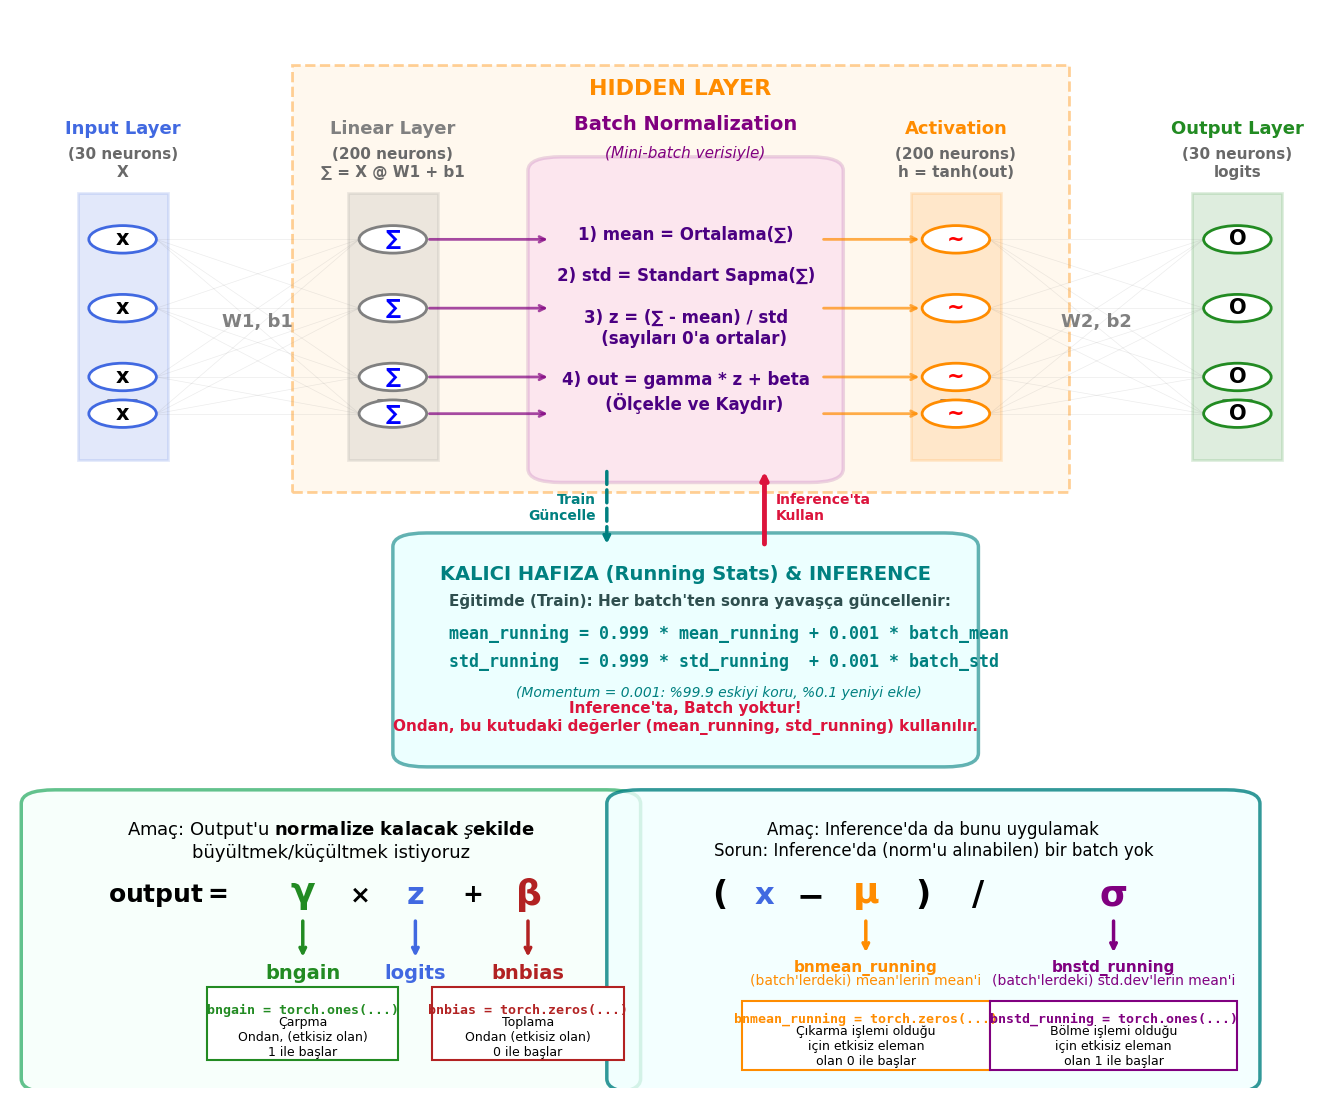

In [41]:
# görselleştirme
fig, ax = plt.subplots(figsize=(17, 14)) # Boyutu aşağı doğru genişlettik
ax.set_xlim(-0.02, 1.15)
ax.set_ylim(-1.25, 1.1) # Sol ve Sağ kutular sığsın diye -1.25'e kadar uzattık
ax.axis('off')

# ==========================================
# 2. GİZLİ KATMAN (HIDDEN LAYER) KAPSAYICI KUTUSU
# ==========================================
hl_x = 0.23
hl_w = 0.69
hl_y = 0.05
hl_h = 0.93

hl_rect = patches.Rectangle((hl_x, hl_y), hl_w, hl_h, linewidth=2, edgecolor='darkorange', facecolor='papayawhip', alpha=0.4, zorder=0, linestyle='dashed')
ax.add_patch(hl_rect)

ax.text(hl_x + hl_w/2, hl_y + hl_h - 0.03, "HIDDEN LAYER", 
        ha='center', va='top', fontsize=16, fontweight='bold', color='darkorange', zorder=1)

# ==========================================
# STANDART KATMAN ÇİZİM FONKSİYONU
# ==========================================
def draw_layer(ax, x_center, y_start, y_end, box_color, label, sub_label, symbol, num_neurons):
    box_width = 0.08
    box_height = y_end - y_start
    rect = patches.Rectangle((x_center - box_width/2, y_start), box_width, box_height, 
                             linewidth=2, edgecolor=box_color, facecolor=box_color, alpha=0.15, zorder=1)
    ax.add_patch(rect)
    
    ax.text(x_center, y_end + 0.12, label, ha='center', va='bottom', fontsize=13, fontweight='bold', color=box_color, zorder=2)
    ax.text(x_center, y_end + 0.03, f"({num_neurons} neurons)\n{sub_label}", ha='center', va='bottom', fontsize=11, color='dimgray', fontweight='bold', zorder=2)
    
    node_ys = [y_end - 0.1, y_end - 0.25, y_end - 0.4, y_start + 0.1]
    
    for y in node_ys:
        circle = patches.Circle((x_center, y), 0.03, edgecolor=box_color, facecolor='white', lw=2, zorder=3)
        ax.add_patch(circle)
        
        sym_color = 'black'
        if symbol == '~': sym_color = 'red'
        elif symbol == '∑': sym_color = 'blue'
        
        ax.text(x_center, y, symbol, ha='center', va='center', fontsize=15, color=sym_color, fontweight='bold', zorder=4)
        
    mid_y = (node_ys[2] + node_ys[3]) / 2
    ax.text(x_center, mid_y, "...", ha='center', va='center', fontsize=24, fontweight='bold', color='gray', zorder=2)
        
    return [(x_center, y) for y in node_ys]

layer_y_start = 0.12
layer_y_end = 0.70

# --- INPUT LAYER ---
input_nodes = draw_layer(ax, 0.08, layer_y_start, layer_y_end, 'royalblue', 'Input Layer', 'X', 'x', 30)

# --- LINEAR LAYER (Çarpım ve Toplam) ---
preact_nodes = draw_layer(ax, 0.32, layer_y_start, layer_y_end, 'gray', 'Linear Layer', '∑ = X @ W1 + b1', '∑', 200)

for ix, iy in input_nodes:
    for px, py in preact_nodes:
        ax.plot([ix + 0.03, px - 0.03], [iy, py], color='gray', alpha=0.15, lw=0.5, zorder=1)
ax.text(0.20, 0.42, "W1, b1", color='gray', fontsize=13, fontweight='bold', ha='center', va='center')


# --- BATCH NORM LAYER (ORTADAKİ KUTU) ---
bn_x = 0.47
bn_w = 0.22
bn_y = 0.1
bn_h = 0.65

bn_rect = patches.FancyBboxPatch((bn_x, bn_y), bn_w, bn_h, boxstyle="round,pad=0.03", 
                                 ec="purple", fc="violet", alpha=0.15, lw=2.5, zorder=2)
ax.add_patch(bn_rect)

ax.text(bn_x + bn_w/2, bn_y + bn_h + 0.08, "Batch Normalization", ha='center', va='bottom', fontsize=14, fontweight='bold', color='purple', zorder=2)
ax.text(bn_x + bn_w/2, bn_y + bn_h + 0.02, "(Mini-batch verisiyle)", ha='center', va='bottom', fontsize=11, color='purple', style='italic', zorder=2)

formula = (
    "1) mean = Ortalama(∑)\n\n"
    "2) std = Standart Sapma(∑)\n\n"
    "3) z = (∑ - mean) / std\n"
    "   (sayıları 0'a ortalar)\n\n"
    "4) out = gamma * z + beta\n"
    "   (Ölçekle ve Kaydır)"
)
ax.text(bn_x + bn_w/2, bn_y + bn_h/2, formula, ha='center', va='center', fontsize=12, fontweight='bold', color='indigo', zorder=3)

for px, py in preact_nodes:
    ax.annotate('', xy=(bn_x-0.01, py), xytext=(px + 0.03, py), 
                arrowprops=dict(arrowstyle="->", color="purple", lw=2, alpha=0.7), zorder=2)


# ==========================================
# 3. KALICI HAFIZA (RUNNING STATS) KUTUSU
# ==========================================
mem_x = 0.35
mem_w = 0.46
mem_y = -0.52
mem_h = 0.45

mem_rect = patches.FancyBboxPatch((mem_x, mem_y), mem_w, mem_h, boxstyle="round,pad=0.03", 
                                 ec="teal", fc="lightcyan", alpha=0.6, lw=2.5, zorder=2)
ax.add_patch(mem_rect)

ax.text(mem_x + mem_w/2, mem_y + mem_h - 0.04, "KALICI HAFIZA (Running Stats) & INFERENCE", ha='center', va='top', fontsize=14, fontweight='bold', color='teal', zorder=3)

ax.text(mem_x + 0.02, mem_y + mem_h - 0.12, "Eğitimde (Train): Her batch'ten sonra yavaşça güncellenir:", ha='left', va='center', fontsize=11, color='darkslategray', fontweight='bold')
ax.text(mem_x + 0.02, mem_y + mem_h - 0.19, "mean_running = 0.999 * mean_running + 0.001 * batch_mean", ha='left', va='center', fontsize=12, color='teal', fontweight='bold', fontfamily='monospace')
ax.text(mem_x + 0.02, mem_y + mem_h - 0.25, "std_running  = 0.999 * std_running  + 0.001 * batch_std", ha='left', va='center', fontsize=12, color='teal', fontweight='bold', fontfamily='monospace')

ax.text(mem_x + mem_w - 0.02, mem_y + mem_h - 0.32, "(Momentum = 0.001: %99.9 eskiyi koru, %0.1 yeniyi ekle)", ha='right', va='center', fontsize=10, color='teal', style='italic')
ax.text(mem_x + mem_w/2, mem_y + 0.04, "Inference'ta, Batch yoktur!\nOndan, bu kutudaki değerler (mean_running, std_running) kullanılır.", ha='center', va='bottom', fontsize=11, color='crimson', fontweight='bold', zorder=3)

arrow_dn_x = bn_x + 0.04
ax.annotate('', xy=(arrow_dn_x, mem_y + mem_h), xytext=(arrow_dn_x, bn_y), 
            arrowprops=dict(arrowstyle="->", color="teal", ls="dashed", lw=2.5), zorder=4)
ax.text(arrow_dn_x - 0.01, (bn_y + mem_y + mem_h)/2, "Train\nGüncelle", ha='right', va='center', fontsize=10, color='teal', fontweight='bold', zorder=5)

arrow_up_x = bn_x + bn_w - 0.04
ax.annotate('', xy=(arrow_up_x, bn_y), xytext=(arrow_up_x, mem_y + mem_h), 
            arrowprops=dict(arrowstyle="->", color="crimson", lw=3.5), zorder=4)
ax.text(arrow_up_x + 0.01, (bn_y + mem_y + mem_h)/2, "Inference'ta\nKullan", ha='left', va='center', fontsize=10, color='crimson', fontweight='bold', zorder=5)


# ==========================================
# 4. SOL KUTU (bngain & bnbias AÇIKLAMALARI)
# ==========================================
lb_x = 0.02
lb_y = -1.23
lb_w = 0.49
lb_h = 0.60

lb_rect = patches.FancyBboxPatch((lb_x, lb_y), lb_w, lb_h, boxstyle="round,pad=0.03", 
                                 ec="mediumseagreen", fc="mintcream", alpha=0.8, lw=2.5, zorder=2)
ax.add_patch(lb_rect)

# 1) Amaç Yazısı (EN ÜSTTE)
desc_str = "Amaç: Output'u $\mathbf{normalize\ kalacak\ \mathit{ş}ekilde}$\nbüyültmek/küçültmek istiyoruz"
ax.text(lb_x + lb_w/2, lb_y + lb_h - 0.08, desc_str, ha='center', va='center', fontsize=13, color='black', zorder=3)

# 2) Formül ve Yunan harfleri (AMACIN ALTINDA)
y_form = lb_y + lb_h - 0.20
# X Koordinatlarını merkezledik ki oklar dümdüz insin
pos_out = lb_x + 0.10
pos_gamma = lb_x + 0.22
pos_times = lb_x + 0.27
pos_z = lb_x + 0.32
pos_plus = lb_x + 0.37
pos_beta = lb_x + 0.42

ax.text(pos_out, y_form, r"$\mathbf{output =}$", ha='center', va='center', fontsize=18, color='black', zorder=3)
ax.text(pos_gamma, y_form, r"$\mathbf{\gamma}$", ha='center', va='center', fontsize=26, color='forestgreen', zorder=3)
ax.text(pos_times, y_form, r"$\mathbf{\times}$", ha='center', va='center', fontsize=18, color='black', zorder=3)
ax.text(pos_z, y_form, r"$\mathbf{z}$", ha='center', va='center', fontsize=22, color='royalblue', zorder=3)
ax.text(pos_plus, y_form, r"$\mathbf{+}$", ha='center', va='center', fontsize=18, color='black', zorder=3)
ax.text(pos_beta, y_form, r"$\mathbf{\beta}$", ha='center', va='center', fontsize=26, color='firebrick', zorder=3)

# 3) Oklari ve Sub-kutu Koordinatlari (TAM DİMDİK AŞAĞI)
y_arrow_start = y_form - 0.05
y_arrow_end = lb_y + 0.25

# --- GAMMA (bngain) OKU VE KUTUSU ---
# xytext: okun başlangıcı, xy: okun ucu
ax.annotate('', xy=(pos_gamma, y_arrow_end + 0.01), xytext=(pos_gamma, y_arrow_start), 
            arrowprops=dict(arrowstyle="->", color="forestgreen", lw=2.5), zorder=3)
ax.text(pos_gamma, y_arrow_end, "bngain", ha='center', va='top', fontsize=14, fontweight='bold', color='forestgreen', zorder=3)

g_box_w, g_box_h = 0.17, 0.16
g_box = patches.Rectangle((pos_gamma - g_box_w/2, lb_y + 0.04), g_box_w, g_box_h, ec='forestgreen', fc='white', lw=1.5, zorder=3)
ax.add_patch(g_box)
ax.text(pos_gamma, lb_y + 0.15, "bngain = torch.ones(...)", ha='center', va='center', fontsize=9.5, color='forestgreen', fontweight='bold', fontfamily='monospace', zorder=4)
ax.text(pos_gamma, lb_y + 0.09, "Çarpma\nOndan, (etkisiz olan)\n1 ile başlar", ha='center', va='center', fontsize=9, color='black', zorder=4)

# --- Z (logits) OKU ---
ax.annotate('', xy=(pos_z, y_arrow_end + 0.01), xytext=(pos_z, y_arrow_start), 
            arrowprops=dict(arrowstyle="->", color="royalblue", lw=2.5), zorder=3)
ax.text(pos_z, y_arrow_end, "logits", ha='center', va='top', fontsize=14, fontweight='bold', color='royalblue', zorder=3)

# --- BETA (bnbias) OKU VE KUTUSU ---
ax.annotate('', xy=(pos_beta, y_arrow_end + 0.01), xytext=(pos_beta, y_arrow_start), 
            arrowprops=dict(arrowstyle="->", color="firebrick", lw=2.5), zorder=3)
ax.text(pos_beta, y_arrow_end, "bnbias", ha='center', va='top', fontsize=14, fontweight='bold', color='firebrick', zorder=3)

b_box_w, b_box_h = 0.17, 0.16
b_box = patches.Rectangle((pos_beta - b_box_w/2, lb_y + 0.04), b_box_w, b_box_h, ec='firebrick', fc='white', lw=1.5, zorder=3)
ax.add_patch(b_box)
ax.text(pos_beta, lb_y + 0.15, "bnbias = torch.zeros(...)", ha='center', va='center', fontsize=9.5, color='firebrick', fontweight='bold', fontfamily='monospace', zorder=4)
ax.text(pos_beta, lb_y + 0.09, "Toplama\nOndan (etkisiz olan)\n0 ile başlar", ha='center', va='center', fontsize=9, color='black', zorder=4)



# --- TANH (ACTIVATION) LAYER ---
tanh_nodes = draw_layer(ax, 0.82, layer_y_start, layer_y_end, 'darkorange', 'Activation', 'h = tanh(out)', '~', 200)

for tx, ty in tanh_nodes:
    ax.annotate('', xy=(tx - 0.03, ty), xytext=(bn_x + bn_w + 0.01, ty), 
                arrowprops=dict(arrowstyle="->", color="darkorange", lw=2, alpha=0.7), zorder=2)


# --- OUTPUT LAYER ---
out_nodes = draw_layer(ax, 1.07, layer_y_start, layer_y_end, 'forestgreen', 'Output Layer', 'logits', 'O', 30)

for tx, ty in tanh_nodes:
    for ox, oy in out_nodes:
        ax.plot([tx + 0.03, ox - 0.03], [ty, oy], color='gray', alpha=0.15, lw=0.5, zorder=1)
ax.text(0.945, 0.42, "W2, b2", color='gray', fontsize=13, fontweight='bold', ha='center', va='center')


# ==========================================
# 5. SAĞ KUTU (bnmean_running & bnstd_running AÇIKLAMALARI)
# ==========================================
rb_x = 0.54
rb_y = -1.23
rb_w = 0.52
rb_h = 0.60

rb_rect = patches.FancyBboxPatch((rb_x, rb_y), rb_w, rb_h, boxstyle="round,pad=0.03", 
                                 ec="teal", fc="azure", alpha=0.8, lw=2.5, zorder=2)
ax.add_patch(rb_rect)

# 1) Amaç ve Sorun Yazısı (KALIN DEĞİL)
desc_rt = "Amaç: Inference'da da bunu uygulamak\nSorun: Inference'da (norm'u alınabilen) bir batch yok"
ax.text(rb_x + rb_w/2, rb_y + rb_h - 0.08, desc_rt, ha='center', va='center', fontsize=12, color='black', zorder=3)

# 2) Formül
y_form = rb_y + rb_h - 0.20

pos_paren_open = rb_x + 0.07
pos_x_sym      = rb_x + 0.11
pos_minus      = rb_x + 0.15
pos_mu         = rb_x + 0.20
pos_paren_close= rb_x + 0.25
pos_div        = rb_x + 0.30
pos_sigma      = rb_x + 0.42 # Kutular çakışmasın diye sağa alındı

ax.text(pos_paren_open, y_form, r"$\mathbf{(}$", ha='center', va='center', fontsize=24, color='black', zorder=3)
ax.text(pos_x_sym, y_form, r"$\mathbf{x}$", ha='center', va='center', fontsize=22, color='royalblue', zorder=3)
ax.text(pos_minus, y_form, r"$\mathbf{-}$", ha='center', va='center', fontsize=24, color='black', zorder=3)
ax.text(pos_mu, y_form, r"$\mathbf{\mu}$", ha='center', va='center', fontsize=26, color='darkorange', zorder=3)
ax.text(pos_paren_close, y_form, r"$\mathbf{)}$", ha='center', va='center', fontsize=24, color='black', zorder=3)
ax.text(pos_div, y_form, r"$\mathbf{/}$", ha='center', va='center', fontsize=24, color='black', zorder=3)
ax.text(pos_sigma, y_form, r"$\mathbf{\sigma}$", ha='center', va='center', fontsize=26, color='purple', zorder=3)

# 3) Oklari ve Sub-kutu Koordinatlari
y_arrow_start = y_form - 0.05
y_arrow_end = rb_y + 0.26

# --- MU (bnmean_running) OKU VE KUTUSU ---
ax.annotate('', xy=(pos_mu, y_arrow_end + 0.01), xytext=(pos_mu, y_arrow_start), 
            arrowprops=dict(arrowstyle="->", color="darkorange", lw=2.5), zorder=3)
# Değişken adı kalın, altındaki açıklama normal!
ax.text(pos_mu, y_arrow_end, "bnmean_running", ha='center', va='top', fontsize=11, fontweight='bold', color='darkorange', zorder=3)
ax.text(pos_mu, y_arrow_end - 0.03, "(batch'lerdeki) mean'lerin mean'i", ha='center', va='top', fontsize=10, color='darkorange', zorder=3)

m_box_w, m_box_h = 0.22, 0.15
m_box = patches.Rectangle((pos_mu - m_box_w/2, rb_y + 0.02), m_box_w, m_box_h, ec='darkorange', fc='white', lw=1.5, zorder=3)
ax.add_patch(m_box)
ax.text(pos_mu, rb_y + 0.13, "bnmean_running = torch.zeros(...)", ha='center', va='center', fontsize=9.5, color='darkorange', fontweight='bold', fontfamily='monospace', zorder=4)
ax.text(pos_mu, rb_y + 0.07, "Çıkarma işlemi olduğu\niçin etkisiz eleman\nolan 0 ile başlar", ha='center', va='center', fontsize=9, color='black', zorder=4)

# --- SIGMA (bnstd_running) OKU VE KUTUSU ---
ax.annotate('', xy=(pos_sigma, y_arrow_end + 0.01), xytext=(pos_sigma, y_arrow_start), 
            arrowprops=dict(arrowstyle="->", color="purple", lw=2.5), zorder=3)
# Değişken adı kalın, altındaki açıklama normal!
ax.text(pos_sigma, y_arrow_end, "bnstd_running", ha='center', va='top', fontsize=11, fontweight='bold', color='purple', zorder=3)
ax.text(pos_sigma, y_arrow_end - 0.03, "(batch'lerdeki) std.dev'lerin mean'i", ha='center', va='top', fontsize=10, color='purple', zorder=3)

s_box_w, s_box_h = 0.22, 0.15
s_box = patches.Rectangle((pos_sigma - s_box_w/2, rb_y + 0.02), s_box_w, s_box_h, ec='purple', fc='white', lw=1.5, zorder=3)
ax.add_patch(s_box)
ax.text(pos_sigma, rb_y + 0.13, "bnstd_running = torch.ones(...)", ha='center', va='center', fontsize=9.5, color='purple', fontweight='bold', fontfamily='monospace', zorder=4)
ax.text(pos_sigma, rb_y + 0.07, "Bölme işlemi olduğu\niçin etkisiz eleman\nolan 1 ile başlar", ha='center', va='center', fontsize=9, color='black', zorder=4)



plt.show()


In [ ]:
# Görev 7: 
    # Geçen haftaki Türkçe isim listenle aynı modeli eğit. 
    # Türkçe'de ürettiği isimlerden örnekler ve dev loss'u göster. 
    # Bigram'ın Türkçe sonuçlarıyla yan yana koy.


words = open('turkish_names_only.txt', 'r', encoding='utf-8').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(stoi)  # Türkçe için 30 olacak!
block_size = 3

print(f"Türkçe kelime sayısı: {len(words)}")
print(f"Türkçe Alfabe (Vocab Size): {vocab_size}")

# VERİ SETİNİ OLUŞTUR
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

# MLP dataset
X_tr, Y_tr = build_dataset(words[:n1])
X_dev, Y_dev = build_dataset(words[n1:n2])
X_te, Y_te = build_dataset(words[n2:])

def get_vocab_size(): return vocab_size
def get_block_size(): return block_size
def prepare_training_set(): return X_tr, Y_tr, X_dev, Y_dev, X_te, Y_te


# BIGRAM NN
print("\n--- 1. Bigram NN Modeli ---")

def get_bigram_xy(word_list):
    xs, ys = [], []
    for word in word_list:
        chs = ['.'] + list(word) + ['.']
        for ch1, ch2 in zip(chs, chs[1:]):
            ix1 = stoi[ch1]
            ix2 = stoi[ch2]
            xs.append(ix1)
            ys.append(ix2)
    return torch.tensor(xs), torch.tensor(ys)

# Bigram için Train ve Dev verilerini ayırıyoruz
xs_tr, ys_tr = get_bigram_xy(words[:n1])
xs_dev, ys_dev = get_bigram_xy(words[n1:n2])

g_bigram = torch.Generator().manual_seed(2147483647)
W_bigram = torch.randn((vocab_size, vocab_size), generator=g_bigram, requires_grad=True)

num_tr = xs_tr.nelement()
for i in range(100):
    xenc = F.one_hot(xs_tr, num_classes=vocab_size).float()
    logits = xenc @ W_bigram
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim=True)
    loss_tr = -probs[torch.arange(num_tr), ys_tr].log().mean() + 0.01*(W_bigram**2).mean()
    
    W_bigram.grad = None 
    loss_tr.backward()
    W_bigram.data += -50 * W_bigram.grad

num_dev = xs_dev.nelement()
xenc_dev = F.one_hot(xs_dev, num_classes=vocab_size).float()
logits_dev = xenc_dev @ W_bigram
counts_dev = logits_dev.exp()
probs_dev = counts_dev / counts_dev.sum(1, keepdim=True)
loss_dev = -probs_dev[torch.arange(num_dev), ys_dev].log().mean()

print(f"Bigram NN Türkçe Train Loss: {loss_tr.item():.4f}")
print(f"Bigram NN Türkçe Dev Loss:   {loss_dev.item():.4f}")

# MLP Modelleri Eğitim + Loss
print("\n--- 2. MLP (BatchNorm YOK) ---")
C_no, W1_no, b1_no, W2_no, b2_no = train_mlp_without_batch_norm(n_embd=10, n_hidden=200, show=False)
split_loss_without_batch_norm('val', C_no, W1_no, b1_no, W2_no, b2_no)

print("\n--- 3. MLP (BatchNorm VAR) ---")
C_bn, W1_bn, b1_bn, W2_bn, b2_bn, bngain, bnbias, bnmean_running, bnstd_running = train_mlp_with_batch_norm(n_embd=10, n_hidden=200, show=False)
split_loss_with_batch_norm('val', C_bn, W1_bn, b1_bn, W2_bn, b2_bn, bngain, bnbias, bnmean_running, bnstd_running)

def generate_mlp(C, W1, b1, W2, b2, bngain=None, bnbias=None, bnmean_running=None, bnstd_running=None):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])] 
        embcat = emb.view(1, -1)
        hpreact = embcat @ W1 + b1
        if bngain is not None: # Batch Norm varsa uygula
            hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
        h = torch.tanh(hpreact)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0: break
    return ''.join(itos[i] for i in out[:-1])

def generate_bigram(W):
    out = []
    ix = 0
    while True:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=vocab_size).float()
        logits = xenc @ W
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        out.append(ix)
        if ix == 0: break
    return ''.join(itos[i] for i in out[:-1])

print("\n" + "="*40)
print("ÖRNEK TÜRKÇE İSİMLER KIYASLAMASI")
print("="*40)

print("\n[ Bigram NN ] (Sadece 1 önceki harfe bakar)")
for _ in range(5): print(generate_bigram(W_bigram))

print("\n[ MLP - BatchNorm YOK ] (3 harflik bağlam)")
for _ in range(5): print(generate_mlp(C_no, W1_no, b1_no, W2_no, b2_no))

print("\n[ MLP - BatchNorm VAR ] (3 harflik bağlam + Stabilite)")
for _ in range(5): print(generate_mlp(C_bn, W1_bn, b1_bn, W2_bn, b2_bn, bngain, bnbias, bnmean_running, bnstd_running))


Türkçe kelime sayısı: 2967
Türkçe Alfabe (Vocab Size): 31

--- 1. Bigram NN Modeli ---
Bigram NN Türkçe Train Loss: 2.4821
Bigram NN Türkçe Dev Loss:   2.4784

--- 2. MLP (BatchNorm YOK) ---
val 2.7930490970611572

--- 3. MLP (BatchNorm VAR) ---
val 2.357992172241211

ÖRNEK TÜRKÇE İSİMLER KIYASLAMASI

[ Bigram NN ] (Sadece 1 önceki harfe bakar)
y
ahagbimekaycar
zılszha
devaye
sazurrabvkap

[ MLP - BatchNorm YOK ] (3 harflik bağlam)
aydun
yakurtsevcima
kayankayhanur
gülşa
yal

[ MLP - BatchNorm VAR ] (3 harflik bağlam + Stabilite)
tay
ahmur
varacettin
kcankayalık
gültekin


In [19]:
print("\n[ MLP - BatchNorm YOK ] (3 harflik bağlam)")
for _ in range(20): print(generate_mlp(C_no, W1_no, b1_no, W2_no, b2_no))

print("\n[ MLP - BatchNorm VAR ] (3 harflik bağlam + Stabilite)")
for _ in range(20): print(generate_mlp(C_bn, W1_bn, b1_bn, W2_bn, b2_bn, bngain, bnbias, bnmean_running, bnstd_running))



[ MLP - BatchNorm YOK ] (3 harflik bağlam)
dilah
lütfi
miksiyar
harrem
meramur
can
cemi
cana
perih
serhan
munzur
haci
altı
fah
turgun
erce
haya
beycansel
ferdenis
mükrü

[ MLP - BatchNorm VAR ] (3 harflik bağlam + Stabilite)
erdağ
rüsgülis
rüssin
piran
hasgülperke
sese
talya
özay
gül
aydan
can
can
mahcupan
zir
ali
bulisa
kay
nesihan
peliha
veddincik


In [ ]:
# Görev 7: 
    # Geçen haftaki Türkçe isim listenle aynı modeli eğit. 
    # Türkçe'de ürettiği isimlerden örnekler ve dev loss'u göster. 
    # Bigram'ın Türkçe sonuçlarıyla yan yana koy.


words = open('turkish_names_and_generated_names.txt', 'r', encoding='utf-8').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(stoi)  # Türkçe için 30 olacak!
block_size = 3

print(f"Türkçe kelime sayısı: {len(words)}")
print(f"Türkçe Alfabe (Vocab Size): {vocab_size}")

# VERİ SETİNİ OLUŞTUR
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

# MLP dataset
X_tr, Y_tr = build_dataset(words[:n1])
X_dev, Y_dev = build_dataset(words[n1:n2])
,X_te, Y_te = buld_dataset(words[n2:])

def get_vocab_size(): return vocab_size
def get_block_size(): return block_size
def prepare_training_set(): return X_tr, Y_tr, X_dev, Y_dev, X_te, Y_te


# BIGRAM NN
print("\n--- 1. Bigram NN Modeli ---")

def get_bigram_xy(word_list):
    xs, ys = [], []
    for word in word_list:
        chs = ['.'] + list(word) + ['.']
        for ch1, ch2 in zip(chs, chs[1:]):
            ix1 = stoi[ch1]
            ix2 = stoi[ch2]
            xs.append(ix1)
            ys.append(ix2)
    return torch.tensor(xs), torch.tensor(ys)

# Bigram için Train ve Dev verilerini ayırıyoruz
xs_tr, ys_tr = get_bigram_xy(words[:n1])
xs_dev, ys_dev = get_bigram_xy(words[n1:n2])

g_bigram = torch.Generator().manual_seed(2147483647)
W_bigram = torch.randn((vocab_size, vocab_size), generator=g_bigram, requires_grad=True)

num_tr = xs_tr.nelement()
for i in range(100):
    xenc = F.one_hot(xs_tr, num_classes=vocab_size).float()
    logits = xenc @ W_bigram
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim=True)
    loss_tr = -probs[torch.arange(num_tr), ys_tr].log().mean() + 0.01*(W_bigram**2).mean()
    
    W_bigram.grad = None 
    loss_tr.backward()
    W_bigram.data += -50 * W_bigram.grad

num_dev = xs_dev.nelement()
xenc_dev = F.one_hot(xs_dev, num_classes=vocab_size).float()
logits_dev = xenc_dev @ W_bigram
counts_dev = logits_dev.exp()
probs_dev = counts_dev / counts_dev.sum(1, keepdim=True)
loss_dev = -probs_dev[torch.arange(num_dev), ys_dev].log().mean()

print(f"Bigram NN Türkçe Train Loss: {loss_tr.item():.4f}")
print(f"Bigram NN Türkçe Dev Loss:   {loss_dev.item():.4f}")

# MLP Modelleri Eğitim + Loss
print("\n--- 2. MLP (BatchNorm YOK) ---")
C_no, W1_no, b1_no, W2_no, b2_no = train_mlp_without_batch_norm(n_embd=10, n_hidden=200, show=False)
split_loss_without_batch_norm('val', C_no, W1_no, b1_no, W2_no, b2_no)

print("\n--- 3. MLP (BatchNorm VAR) ---")
C_bn, W1_bn, b1_bn, W2_bn, b2_bn, bngain, bnbias, bnmean_running, bnstd_running = train_mlp_with_batch_norm(n_embd=10, n_hidden=200, show=False)
split_loss_with_batch_norm('val', C_bn, W1_bn, b1_bn, W2_bn, b2_bn, bngain, bnbias, bnmean_running, bnstd_running)

def generate_mlp(C, W1, b1, W2, b2, bngain=None, bnbias=None, bnmean_running=None, bnstd_running=None):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])] 
        embcat = emb.view(1, -1)
        hpreact = embcat @ W1 + b1
        if bngain is not None: # Batch Norm varsa uygula
            hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
        h = torch.tanh(hpreact)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0: break
    return ''.join(itos[i] for i in out[:-1])

def generate_bigram(W):
    out = []
    ix = 0
    while True:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=vocab_size).float()
        logits = xenc @ W
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        out.append(ix)
        if ix == 0: break
    return ''.join(itos[i] for i in out[:-1])

print("\n" + "="*40)
print("ÖRNEK TÜRKÇE İSİMLER KIYASLAMASI")
print("="*40)

print("\n[ Bigram NN ] (Sadece 1 önceki harfe bakar)")
for _ in range(5): print(generate_bigram(W_bigram))

print("\n[ MLP - BatchNorm YOK ] (3 harflik bağlam)")
for _ in range(5): print(generate_mlp(C_no, W1_no, b1_no, W2_no, b2_no))

print("\n[ MLP - BatchNorm VAR ] (3 harflik bağlam + Stabilite)")
for _ in range(5): print(generate_mlp(C_bn, W1_bn, b1_bn, W2_bn, b2_bn, bngain, bnbias, bnmean_running, bnstd_running))


Türkçe kelime sayısı: 9040
Türkçe Alfabe (Vocab Size): 31

--- 1. Bigram NN Modeli ---
Bigram NN Türkçe Train Loss: 2.4104
Bigram NN Türkçe Dev Loss:   2.3921

--- 2. MLP (BatchNorm YOK) ---
val 1.8264046907424927

--- 3. MLP (BatchNorm VAR) ---
val 1.7791544198989868

ÖRNEK TÜRKÇE İSİMLER KIYASLAMASI

[ Bigram NN ] (Sadece 1 önceki harfe bakar)
ev
k
dertay
ifersyde
ozçpkun

[ MLP - BatchNorm YOK ] (3 harflik bağlam)
umkurt
dilliz
tolla
alper
sevıldeniz

[ MLP - BatchNorm VAR ] (3 harflik bağlam + Stabilite)
sönden
alşah
zavakıl
devihan
tekir


In [21]:
print("\n[ MLP - BatchNorm YOK ] (3 harflik bağlam)")
for _ in range(50): print(generate_mlp(C_no, W1_no, b1_no, W2_no, b2_no))

print("\n[ MLP - BatchNorm VAR ] (3 harflik bağlam + Stabilite)")
for _ in range(50): print(generate_mlp(C_bn, W1_bn, b1_bn, W2_bn, b2_bn, bngain, bnbias, bnmean_running, bnstd_running))



[ MLP - BatchNorm YOK ] (3 harflik bağlam)
korgim
merttaş
alhasi
asgun
soner
orbey
ilca
astin
dilıl
demiraclal
ceydaş
fıt
ünmiray
mutabib
nejtin
seçzer
tuğtankı
ilge
mutzer
gülliz
göçmen
balbakil
yücer
baltuğkın
dilsel
ekibe
hayraman
abdullah
yücesoy
seygan
vuruttaş
arkim
aziziye
asilhammez
berkgan
til
egetettin
mutver
orkurt
çağsu
aksantekşan
alpdeniz
berkşan
balbige
batşener
yaltan
efesime
şen
süheysel
yücelit

[ MLP - BatchNorm VAR ] (3 harflik bağlam + Stabilite)
refika
afidan
ordan
tujiltin
savtiye
bozkun
pamdemnuray
yetişım
abdürbildan
göçgün
habatur
tan
durkın
sever
şerçin
pami
uman
asşin
efebay
kornaz
aysoy
ebrit
sel
yetişfidan
özmir
egeıl
din
karslan
barusil
mürkun
doğbatdeniz
vurok
tolbige
yenbey
erberkkin
iltay
olcaycerurdar
evba
tanal
özdaluz
iltuğ
ceysifi
nurmir
pamen
sevgin
çetsay
gülçin
sel
fegin
toyskurtuğsu


In [ ]:
# (Ek) Görev 8: 
    ## Karpathy'nin video altındaki egzersizlerinden birini seç: 
        ### Bütün weight ve bias'ları sıfırla başlat
        ### Ağı eğit
        ### Neyin kısmen öğrendiğini gradient ve aktivasyonlardan bul
    ## Ya da BatchNorm'u eğitimden sonra bir önceki Linear katmanın W ve b'sine katla, forward pass'in aynı kaldığını göster
    ## Ya da hiperparametreleri ayarlayıp Karpathy'nin 2.2 validation loss'unu geç


words = open('names.txt', 'r').read().splitlines()

# karakter sözlüğü oluşturma
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

def get_vocab_size():
    return len(itos)

def get_block_size():
    return 3


def init_variables_mlp_custom_2(n_embd, n_hidden):
    vocab_size = get_vocab_size()
    block_size = get_block_size()

    g = torch.Generator().manual_seed(2147483647)
    C  = torch.randn((vocab_size, n_embd),            generator=g)

    W1 = torch.zeros((n_embd * block_size, n_hidden))
    b1 = torch.zeros(n_hidden,                      )
    W2 = torch.zeros((n_hidden, vocab_size),        )
    b2 = torch.zeros(vocab_size,                    )

    parameters = [C,W1,b1,W2,b2]

    for p in parameters:
        p.requires_grad = True

    return g,C,W1,b1,W2,b2, parameters

def train_mlp_without_batch_norm_custom(n_embd, n_hidden, step_size=200000, batch_size=32):
    g,C,W1,b1,W2,b2, parameters = init_variables_mlp_custom_2(n_embd, n_hidden)

    lossi = []

    for i in range(step_size):
        ix = torch.randint(0 ,X_tr.shape[0], (batch_size,), generator=g)
        X_batch, Y_batch = X_tr[ix], Y_tr[ix]

        embs = C[X_batch]

        embs = embs.view(embs.shape[0], -1)
        h = torch.tanh(embs @ W1 + b1)

        logits = h @ W2 + b2

        loss = F.cross_entropy(logits, Y_batch)


        for p in parameters:
            p.grad = None
        loss.backward()
        lr = 0.1 if i < 100000 else 0.01
        for p in parameters:
            p.data += -lr * p.grad
            
        if i % 10000 == 0:
            print(f'{i:7d}/{step_size:7d}: {loss.item():.4f}')
            lossi.append(loss.log10().item())
    return g, C, W1, b1, W2, b2


@torch.no_grad()
def split_loss_without_batch_norm_custom(split, C, W1, b1, W2, b2):
    x, y = {'train': (X_tr, Y_tr), 'val': (X_dev, Y_dev), 'test': (X_te, Y_te)}[split]

    emb = C[x]
    emb = emb.view(emb.shape[0], -1)
    h = torch.tanh(emb @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)

    print(split, loss.item())

X_tr, Y_tr, X_dev, Y_dev, X_te, Y_te = prepare_training_set()
g, C, W1, b1, W2, b2 = train_mlp_without_batch_norm_custom(n_embd=10, n_hidden=200)

split_loss_without_batch_norm_custom('train', C, W1, b1, W2, b2)
split_loss_without_batch_norm_custom('val', C, W1, b1, W2, b2)


# görselleştirme

# 1) Tek bir batch alıp ileri-geri yapalım
ix = torch.randint(0, X_tr.shape[0], (32,), generator=g)
X_batch, Y_batch = X_tr[ix], Y_tr[ix]

embs = C[X_batch]
embs = embs.view(embs.shape[0], -1)
h = torch.tanh(embs @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_batch)

# h gradyanını tut
h.retain_grad()

for p in [C, W1, b1, W2, b2]:
    p.grad = None
loss.backward()

# ----------------------------------------------------
# 1. ACTIVATION DISTRIBUTION (Aktivasyon Dağılımı)
# ----------------------------------------------------
print('layer 1 (      Tanh): mean %+.2f, std %.2f, saturated: %.2f%%' % 
      (h.mean(), h.std(), (h.abs() > 0.97).float().mean()*100))

plt.figure(figsize=(20, 4))
hy, hx = torch.histogram(h, density=True)
plt.plot(hx[:-1].detach(), hy.detach(), lw=2, color='blue')
plt.title('activation distribution')
plt.legend(['layer 1 (Tanh)'])
plt.show()


# ----------------------------------------------------
# 2. GRADIENT DISTRIBUTION (Aktivasyon Gradyanları)
# ----------------------------------------------------
print('layer 1 (      Tanh): mean %+.6f, std %e' % (h.grad.mean(), h.grad.std()))

plt.figure(figsize=(20, 4))
hy, hx = torch.histogram(h.grad, density=True)
plt.plot(hx[:-1].detach(), hy.detach(), lw=2, color='red')
plt.title('gradient distribution (h.grad)')
plt.legend(['layer 1 (Tanh)'])
plt.show()


# ----------------------------------------------------
# 3. WEIGHT GRADIENT DISTRIBUTION (Ağırlık Gradyanları)
# ----------------------------------------------------
print('W1: mean %+.6f, std %e' % (W1.grad.mean(), W1.grad.std()))
print('W2: mean %+.6f, std %e' % (W2.grad.mean(), W2.grad.std()))

plt.figure(figsize=(20, 4))
# W1
hy, hx = torch.histogram(W1.grad, density=True)
plt.plot(hx[:-1].detach(), hy.detach(), lw=2, color='green')
# W2
hy, hx = torch.histogram(W2.grad, density=True)
plt.plot(hx[:-1].detach(), hy.detach(), lw=2, color='orange')

plt.title('weight gradient distribution')
plt.legend(['W1.grad', 'W2.grad'])
plt.show()



      0/ 200000: 3.2958
  10000/ 200000: 2.7882
  20000/ 200000: 2.7518
  30000/ 200000: 2.8506
  40000/ 200000: 2.8221
  50000/ 200000: 2.8987
  60000/ 200000: 2.6038
  70000/ 200000: 2.6751
  80000/ 200000: 3.0131
  90000/ 200000: 2.7753
 100000/ 200000: 2.6079
 110000/ 200000: 2.5352
 120000/ 200000: 2.6702
 130000/ 200000: 2.6442
 140000/ 200000: 2.8332
 150000/ 200000: 2.5482
 160000/ 200000: 2.9762
 170000/ 200000: 2.9521
 180000/ 200000: 2.8626
 190000/ 200000: 2.8505
train 2.8226735591888428
val 2.8210439682006836


      0/ 200000: 3.2958
  10000/ 200000: 2.7882
  20000/ 200000: 2.7518
  30000/ 200000: 2.8506
  40000/ 200000: 2.8221
  50000/ 200000: 2.8987
  60000/ 200000: 2.6038
  70000/ 200000: 2.6751
  80000/ 200000: 3.0131
  90000/ 200000: 2.7753
 100000/ 200000: 2.6079
 110000/ 200000: 2.5352
 120000/ 200000: 2.6702
 130000/ 200000: 2.6442
 140000/ 200000: 2.8332
 150000/ 200000: 2.5482
 160000/ 200000: 2.9762
 170000/ 200000: 2.9521
 180000/ 200000: 2.8626
 190000/ 200000: 2.8505
train 2.8226735591888428
val 2.8210439682006836
layer 1 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%


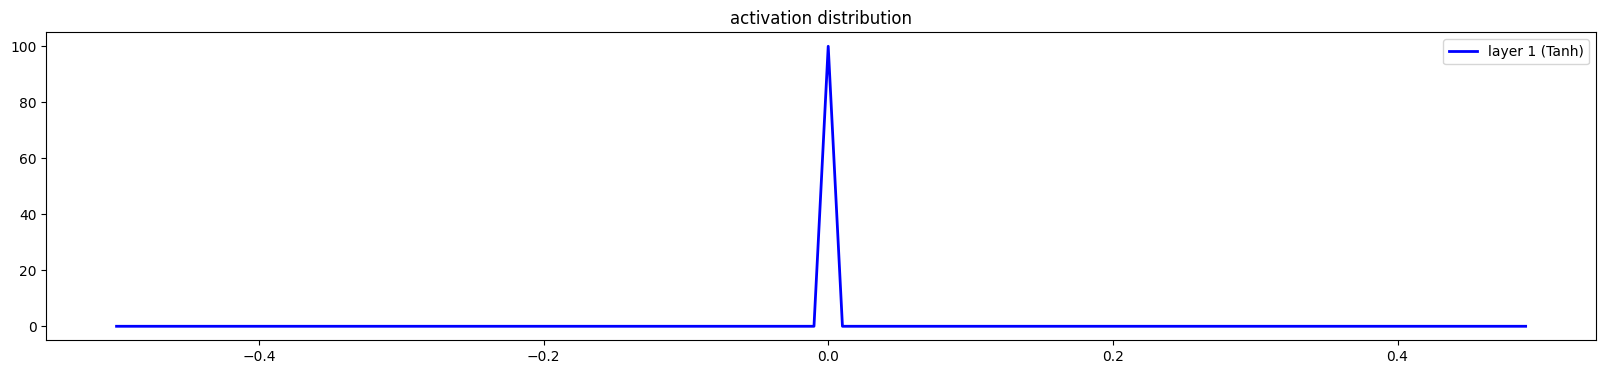

layer 1 (      Tanh): mean +0.000000, std 0.000000e+00


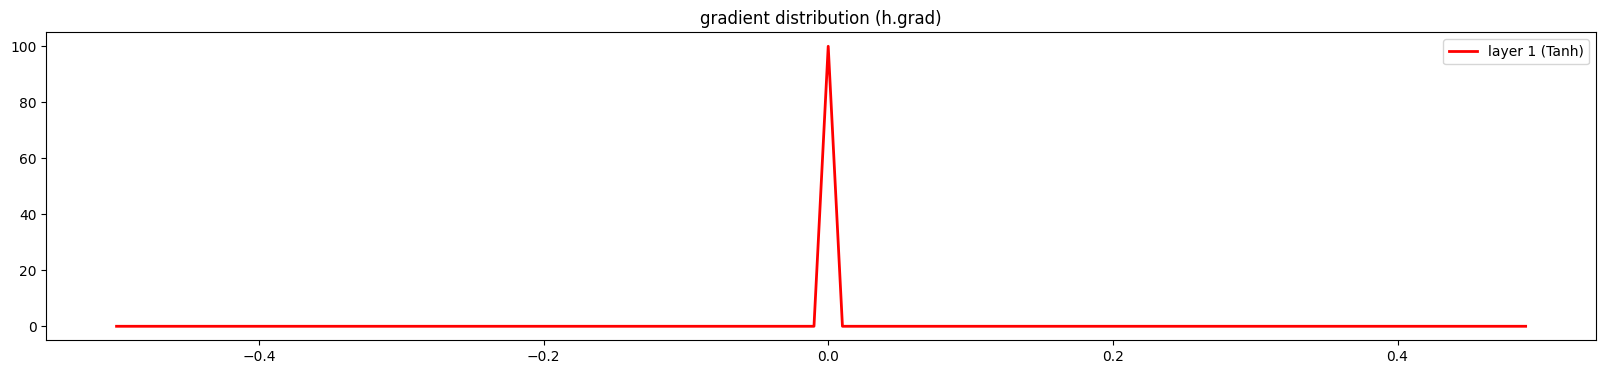

W1: mean +0.000000, std 0.000000e+00
W2: mean +0.000000, std 0.000000e+00


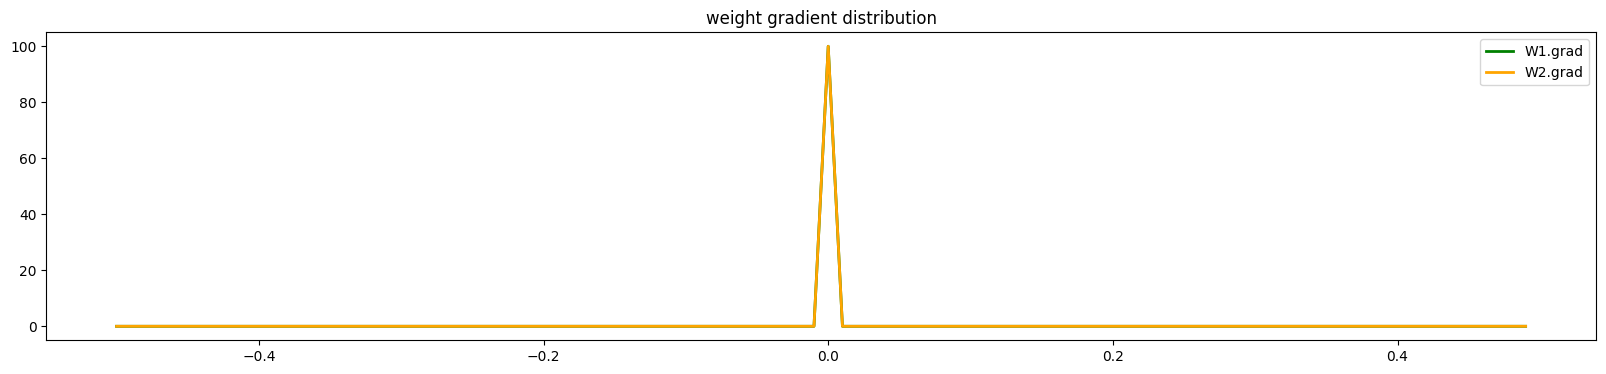

In [17]:
def init_variables_mlp_custom_2(n_embd, n_hidden):
    vocab_size = get_vocab_size()
    block_size = get_block_size()

    g = torch.Generator().manual_seed(2147483647)
    C  = torch.randn((vocab_size, n_embd),            generator=g)

    W1 = torch.zeros((n_embd * block_size, n_hidden))
    b1 = torch.zeros(n_hidden,                      )
    W2 = torch.zeros((n_hidden, vocab_size),        )
    b2 = torch.zeros(vocab_size,                    )

    bn_gain = torch.ones((1, n_hidden))
    bn_bias = torch.zeros((1, n_hidden))

    bn_runningmean = torch.zeros((1, n_hidden))
    bn_runningstddev = torch.ones((1, n_hidden))

    parameters = [C,W1,b1,W2,b2, bn_gain, bn_bias]

    for p in parameters:
        p.requires_grad = True

    return g,C,W1,b1,W2,b2, parameters, bn_gain, bn_bias, bn_runningmean, bn_runningstddev

def train_mlp_with_batch_norm_custom(n_embd, n_hidden, step_size=200000, batch_size=32):
    g,C,W1,b1,W2,b2, parameters, bn_gain, bn_bias, bn_runningmean, bn_runningstddev = init_variables_mlp_custom_2(n_embd, n_hidden)

    lossi = []

    for i in range(step_size):
        ix = torch.randint(0 ,X_tr.shape[0], (batch_size,), generator=g)
        X_batch, Y_batch = X_tr[ix], Y_tr[ix]

        embs = C[X_batch]
        embs = embs.view(embs.shape[0], -1)
        h_before_bn = embs @ W1 + b1

        batch_mean = h_before_bn.mean(0,keepdim=True)
        batch_std  = h_before_bn.std(0, keepdim=True)

        with torch.no_grad():
            bn_runningmean   = 0.999 * bn_runningmean   + 0.001 * batch_mean
            bn_runningstddev = 0.999 * bn_runningstddev + 0.001 * batch_std
        
        h_bn = bn_gain * ((h_before_bn - batch_mean) / (batch_std + 1e-5) ) + bn_bias
        h = torch.tanh(h_bn)

        logits = h @ W2 + b2
        loss = F.cross_entropy(logits, Y_batch)


        for p in parameters:
            p.grad = None
        loss.backward()
        lr = 0.1 if i < 100000 else 0.01
        for p in parameters:
            p.data += -lr * p.grad
            
        if i % 10000 == 0:
            print(f'{i:7d}/{step_size:7d}: {loss.item():.4f}')
            lossi.append(loss.log10().item())
    return C, W1, b1, W2, b2, bn_gain, bn_bias, bn_runningmean, bn_runningstddev


@torch.no_grad()
def split_loss_with_batch_norm_custom(split, C, W1, b1, W2, b2, bngain, bnbias, bnmean_running, bnstd_running):
    x, y = {'train': (X_tr, Y_tr), 'val': (X_dev, Y_dev), 'test': (X_te, Y_te)}[split]
    
    emb = C[x]
    emb = emb.view(emb.shape[0], -1)
    h_before_bn = emb @ W1 + b1
    h_bn = bngain * ( (h_before_bn - bnmean_running) / (bnstd_running + 1e-5) ) + bnbias
    h = torch.tanh(h_bn)

    logits = h @ W2 + b2

    loss = F.cross_entropy(logits, y)

    print(split, loss.item())


#X_tr, Y_tr, X_dev, Y_dev, X_te, Y_te = prepare_training_set()
C, W1, b1, W2, b2, bngain, bnbias, bnmean_running, bnstd_running = train_mlp_with_batch_norm_custom(n_embd=10, n_hidden=200)

split_loss_with_batch_norm_custom('train', C, W1, b1, W2, b2, bngain, bnbias, bnmean_running, bnstd_running)
split_loss_with_batch_norm_custom('val', C, W1, b1, W2, b2, bngain, bnbias, bnmean_running, bnstd_running)

# görselleştirme

# 1) Tek bir batch alıp ileri-geri yapalım
ix = torch.randint(0, X_tr.shape[0], (32,), generator=g)
X_batch, Y_batch = X_tr[ix], Y_tr[ix]

embs = C[X_batch]
embs = embs.view(embs.shape[0], -1)
h = torch.tanh(embs @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_batch)

# h gradyanını tut
h.retain_grad()

for p in [C, W1, b1, W2, b2]:
    p.grad = None
loss.backward()

# ----------------------------------------------------
# 1. ACTIVATION DISTRIBUTION (Aktivasyon Dağılımı)
# ----------------------------------------------------
print('layer 1 (      Tanh): mean %+.2f, std %.2f, saturated: %.2f%%' % 
      (h.mean(), h.std(), (h.abs() > 0.97).float().mean()*100))

plt.figure(figsize=(20, 4))
hy, hx = torch.histogram(h, density=True)
plt.plot(hx[:-1].detach(), hy.detach(), lw=2, color='blue')
plt.title('activation distribution')
plt.legend(['layer 1 (Tanh)'])
plt.show()


# ----------------------------------------------------
# 2. GRADIENT DISTRIBUTION (Aktivasyon Gradyanları)
# ----------------------------------------------------
print('layer 1 (      Tanh): mean %+.6f, std %e' % (h.grad.mean(), h.grad.std()))

plt.figure(figsize=(20, 4))
hy, hx = torch.histogram(h.grad, density=True)
plt.plot(hx[:-1].detach(), hy.detach(), lw=2, color='red')
plt.title('gradient distribution (h.grad)')
plt.legend(['layer 1 (Tanh)'])
plt.show()


# ----------------------------------------------------
# 3. WEIGHT GRADIENT DISTRIBUTION (Ağırlık Gradyanları)
# ----------------------------------------------------
print('W1: mean %+.6f, std %e' % (W1.grad.mean(), W1.grad.std()))
print('W2: mean %+.6f, std %e' % (W2.grad.mean(), W2.grad.std()))

plt.figure(figsize=(20, 4))
# W1
hy, hx = torch.histogram(W1.grad, density=True)
plt.plot(hx[:-1].detach(), hy.detach(), lw=2, color='green')
# W2
hy, hx = torch.histogram(W2.grad, density=True)
plt.plot(hx[:-1].detach(), hy.detach(), lw=2, color='orange')

plt.title('weight gradient distribution')
plt.legend(['W1.grad', 'W2.grad'])
plt.show()



In [ ]:
# hataları plot etmek nn deki

    ## (başlamadan önce)
    ## (!!!!!!!) ÖNEMLİ NOT (!!!!!!!)
        ### -> Batch Norm yapınca önemi kalmıyo weightlerin (ne ile çarptığının)
            ##### -> Sorun: Weightlerin veya inputların büyük/küçük kaçması ya
            ##### Her türlü normalize edince büyük-küçük kalmıyo
        ### Ondan, tüm bu sorunlar otomatikman çözülüyo batch norm ile
    
    ## (genel kural)
        ### 1) layer'lar arası dağılımlar hep iç içe olmalı 
        ### 2) layerlar arası ilerlediçe, sonlardaki layer'lar sönümlenmiş mi vs. bak
            #### genel resme kapılma



# tanh activation
    ## x ekseni (-1 , 1) output - y ekseni değer adedi (o output değerinden kaç tane var)
    ## -> doğrusu:
        ### 1) x ekseni boyunca yayılmalı/spread olmalı
            #### x eksenindek spread'e (yayılıma) bak
            #### (-1 , 1) arası her değere uzanır mı?
            #### yoksa (-0.75 , 0.75) gibi genişliği daha mı az
                ##### => genişlik neden azalabilir?
                    ###### tanh, squashing function
                    ###### yani, -1 ile 1 arasına sıkıştırır her şeyi
                    ###### ondan, hep bi küçültme eğilimi var
                        ####### videodaki 1 yerine 5/3 ün işe yarama sebebi de bu
                        ####### değerleri büyütemiyoz *1 ile (*5/3 büyük tutabiliyor)
                ##### -> çözüm: 5/3 gibi büyük bir gain kullan
        ### 2) y ekseni boyunca, benzer sıklıklarda olmalı değerler
            #### "-1 ve 1 kısmı patlamış/uçmuş; diğer kısımlar değeri azıcık" gibi de olmamalı
                ##### => bu neden olabilir?
                    ###### çook büyük değerler geliyor ki input olarak
                    ###### output hep sınır max değer çıkıyo
                ##### -> çözüm: w'yu küçült
                    ###### * 0.1 fln yaparak mesela, küçült
            #### "0 da da toplanmamalı"
                ##### => bu neden olabilir?
                    ###### çook küçük output üretiyor
                    ###### weight küçültülmüş büyük ihtimal - desteklnemesi lazım
                ##### -> çözüm: w'yu büyüt
                    ##### * 5/3 fln yaparak

# gradients
    ## x ekseni -> grad değerleri  -  y ekseni -> grad değerlerinin adedi
    ## Her bir neuron'un (sahip olduğu) grad değerlerine bakıyoruz
        ### -> "0 etrafında toplanmak" doğal/olması gereken
            ### -> grad update etmek, "stable" olması gereken bi şey
                #### uniform değerler olmamalı
                #### çook büyük veya aşşırı küçük değerler olmamalı
                    ##### 0.01 , 0.1 tarzı normal değerler olacak
                    ##### weight dediğin, stable şekilde update edilir
        ## => hangi .grad'ın değerleri?
            ### -> (!!) tanh'ın output'unun (h.grad) bu
            ### weightlerin değil
    ## -> doğrusu:
        ### 0 etrafında toplanır... 
        ### ne çok büyük ne çok küçüktür
    ## -> yanlış:
        ### 0 da aşşırı pik var, kalan kısımların sayısı 0'a yakın fln
            ### ayrıca, layer layer ilerledikçe, sönümleniyor pik noktası bile
                #### vanishing gradients oldu
            ### => neden olabilir?
                #### weight'ler küçük diye
                    ##### *5/3 yap mesela; *1 ise
                #### non-linearity yok diye
                    ### tanh() ları kaldırdı hep videoda
                        #### linear oldu, basit oldu, weight update'ler 0'a yakın oldu

# weights gradients
    ## bu, Weigthlerin gradient tablosu
    ## üstteki ile tamaamen aynı inceleme mantığı-yanlışlar vs. var


[images/good_activation_dist.png]


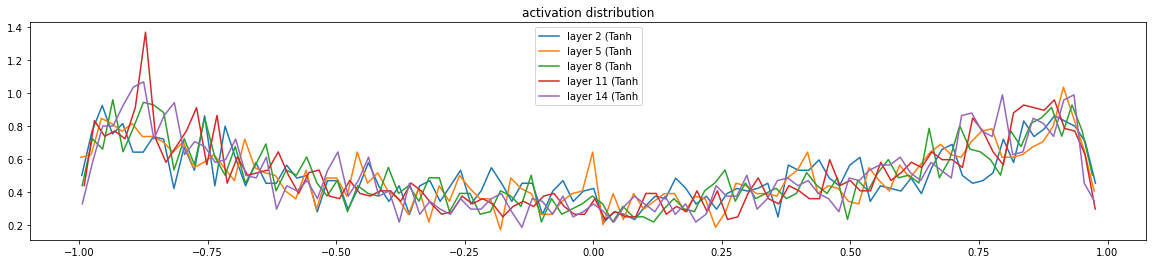


[images/bad_activation_dist.png]


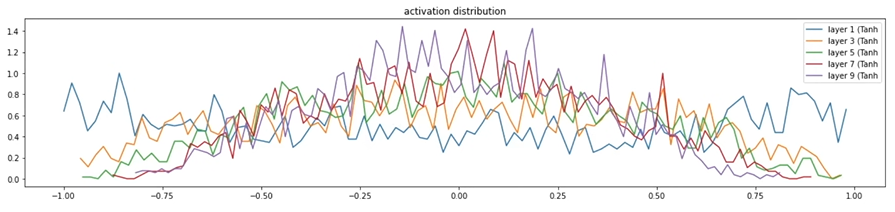


[images/good_grad_dist.png]


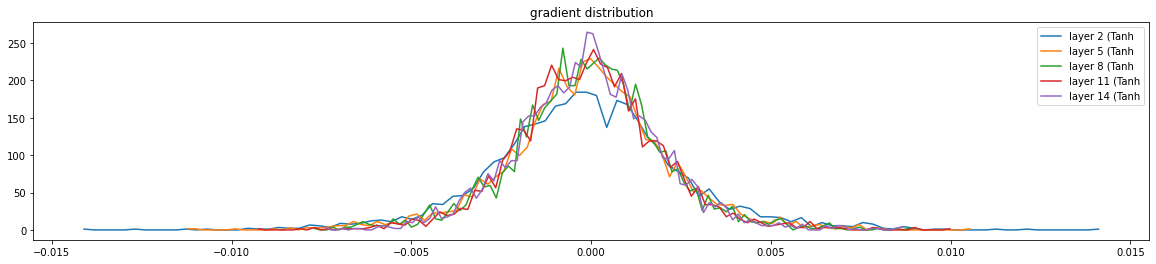


[images/bad_grad_dist.png]


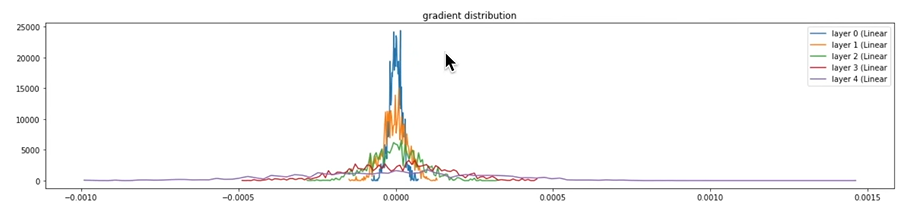


[images/good_weights_dist.png]


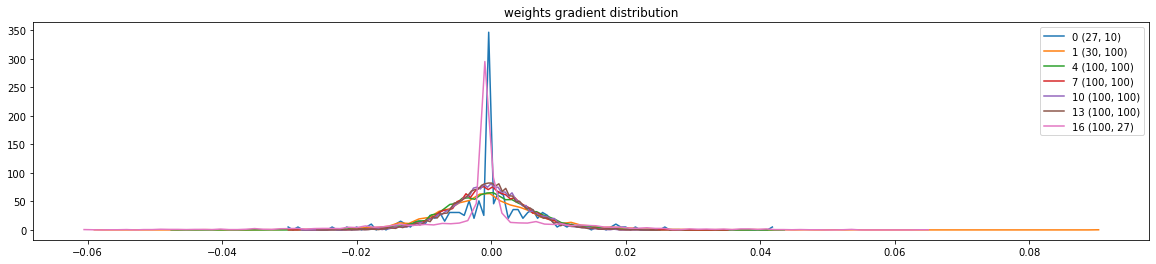

In [ ]:
# görselleştirme
from IPython.display import display, Image

# Gösterilecek resimlerin yolları
resimler = [
    'images/good_activation_dist.png',
    'images/bad_activation_dist.png',
    'images/good_grad_dist.png',
    'images/bad_grad_dist.png',
    'images/good_weights_dist.png'
]

for resim in resimler:
    # Hangi resmin yüklendiğini üstüne başlık olarak yazdırır
    print(f"\n[{resim}]") 
    # Resmi ekrana basar (width ile boyutunu ayarlayabilirsin)
    display(Image(filename=resim, width=800))


In [ ]:
# yaptığım hatalar

# (!!!!!!!!!!!!!!!!!!!!!!!!!) KRİTİK HATA (!!!!!!!!!!!!!!!!!!!!!!!!!)
## -> olması gereken: önce datayı (words'ü) shuffle et; sonra X,Y oluştur
    ### shuffled olan üzerinde gez
## -> yağtığım hata: önce X, Y oluşturdum (words sıralı)... sonra tr, dev aurıdım
    ### => sorun ne? words'e shuffle etmeden baktım
    ### ondan, "a-v harfleri ile başlayanlar" train; "y" dev; "z" test oldu
        #### test'te, "a,b,c,...,m,...v" yok mesela


# Dataset oluştururken, baş harfi büyük unuttum
## -> SONUÇ: Model performansı arttı!!!
    ### Çünkü, position hakkında kopya veriyor
## -> Ama bu KÖTÜ
    ### kopya verdiği için